# SHAP compute — modular pipeline

This notebook drives `utils.shap_runner.compute_shap_for_run` against orchestrator runs. It:

1. Rebuilds the same `X` and `dates` that were used during training. `X` must match the training X column-for-column, or the saved scalers will refuse it.
2. Points at one orchestrator run folder and computes top-k-ensemble-averaged SHAP values per (date, maturity, feature).
3. Saves results under `artifacts/shap/<run_name>/<run_timestamp>/`.
4. Plots some basic SHAP-over-time and top-feature views.

**Start small.** The default config below picks 5 evenly-spaced dates and a single maturity so you can verify everything end-to-end in under a minute. Scale up after the smoke test passes.

In [3]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from utils.shap_runner import ShapRunConfig, compute_shap_for_run

import utils.base_utils as bu
from utils.macro_grouping import add_group_level, build_full_group_mapping

/Users/trineberntsensaether/anaconda3/envs/thesis_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:


# Mirrors the data-prep in notebooks/PCA_PLS_results.ipynb: naive 1-month shift
# for publication lag (no per-series registry), drop the two FRED series that
# start late, then build a 3-level MultiIndex X = (source, group, series).
#
# IMPORTANT: this X must match the X used when the orchestrator run's
# checkpoints were trained. If the training notebook used a different
# publication-lag scheme, the saved StandardScaler will refuse your X with a
# feature-count mismatch. Retrain the model rather than hack the X.

start_date = '1971-08-31'
end_date = '2018-12-31'

yields = bu.get_yields(type='lw', start=start_date, end=end_date,
                       maturities=[str(i) for i in range(12, 121) if i % 12 == 0])
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()

fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data(str(REPO_ROOT / 'data' / '2026-01-MD.csv'),
                               start=fred_md_start_date, end=end_date)

fred_md = fred_md_raw.shift(1)
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
fred_md = fred_md[start_date:end_date]

yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1,
              keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

dates = xr.index
print('X shape:', X.shape, '| dates:', dates[0].date(), '->', dates[-1].date())

X shape: (557, 144) | dates: 1971-08-31 -> 2017-12-31


/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


## Scale up — full sweep for both macro ANN runs

Runs SHAP on every OOS date and all six maturities for both `macro_forward_ann_valid_3_5seeds` and `group_ensemble_ann_valid_fwd3_grp3_5seeds`. `overwrite=False` so the loop is resumable if the kernel dies.

Rough cost: ~336 dates × 6 maturities × 2 seeds = ~4000 DeepSHAP calls per run. On CPU each call on a 144-feature MLP is sub-second, so expect on the order of 20–60 minutes per run. Results land under `artifacts/shap/<run_name>/<run_timestamp>/`; downstream cells read them from there.

In [5]:
artifacts_root = (REPO_ROOT / 'artifacts' / 'orchestrator_runs').resolve()

def latest_run_dir(run_name):
    run_root = artifacts_root / run_name
    stamps = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not stamps:
        raise FileNotFoundError(f'No timestamped runs under {run_root}')
    return stamps[-1]

In [7]:
import time

sweep_run_names = [
    'macro_forward_ann_valid_3_5seeds',
    'group_ensemble_ann_valid_fwd3_grp3_5seeds',
]
sweep_summaries = {}

for rn in sweep_run_names:
    t0 = time.time()
    cfg = ShapRunConfig(
        orchestrator_run_dir=latest_run_dir(rn),
        dates='all',
        maturities=['24', '36', '48', '60', '84', '120'],
        background_size=64,
        explainer='deep',
        apply_y_scaling=True,
        y_center_default=False,
        output_root=str(REPO_ROOT / 'artifacts' / 'shap'),
        overwrite=False,  # resume-friendly
        progress=True,
        save_per_seed=True,
        save_per_seed_meta=True,
    )
    s = compute_shap_for_run(cfg, X=X, dates=dates)
    sweep_summaries[rn] = s
    print(
        f'output_dir={s["output_dir"]} elapsed={time.time() - t0:.0f}s'
    )

sweep_summaries

output_dir=/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/shap/macro_forward_ann_valid_3_5seeds/20260422_103724 elapsed=3s


output_dir=/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101 elapsed=3s


{'macro_forward_ann_valid_3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/shap/macro_forward_ann_valid_3_5seeds/20260422_103724',
  'n_dates_total': 336,
  'n_dates_written_this_call': 0,
  'n_dates_already_present': 336,
  'elapsed_s': 3.26,
  'additivity_error_mean': None,
  'additivity_error_max': None,
  'feature_names_head': ['forward::Yields::108',
   'forward::Yields::12',
   'forward::Yields::120',
   'forward::Yields::24',
   'forward::Yields::36']},
 'group_ensemble_ann_valid_fwd3_grp3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101',
  'n_dates_total': 336,
  'n_dates_written_this_call': 0,
  'n_dates_already_present': 336,
  'elapsed_s': 3.19,
  'additivity_error_mean': None,
  'additivity_error_max': None,
  'feature_names_head': ['forward::Yields::108',
   'forward::Yi

## Plotting

Top 3 features by mean |SHAP|: ['fred::Output and Income::IPCONGD', 'fred::Labor Market::SRVPRD', 'fred::Output and Income::IPMANSICS', 'fred::Interest and Exchange Rates::AAA', 'fred::Interest and Exchange Rates::GS10', 'fred::Interest and Exchange Rates::TB6MS', 'fred::Output and Income::IPFPNSS', 'fred::Prices::CPIMEDSL', 'fred::Labor Market::PAYEMS', 'fred::Output and Income::INDPRO']


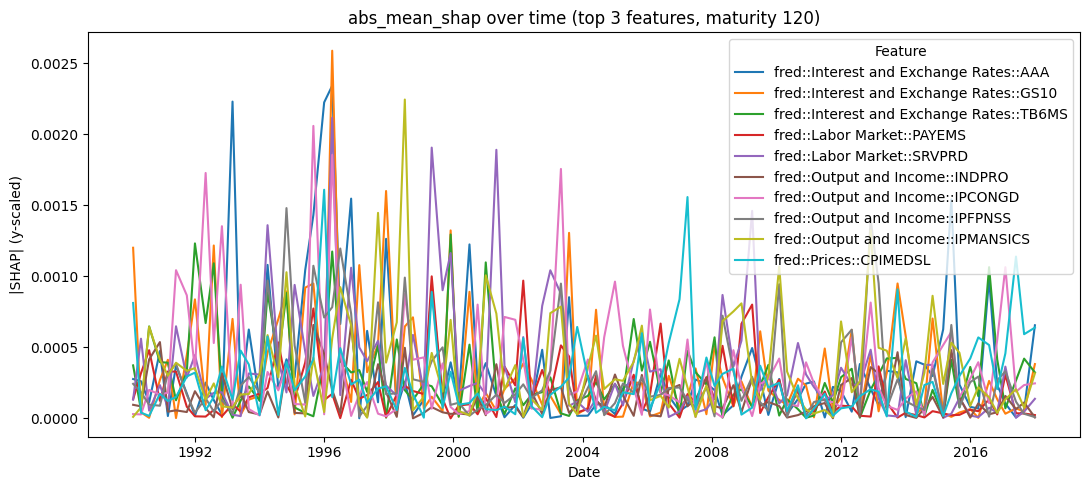

In [102]:
import matplotlib.pyplot as plt

plot_maturity = '120'
df = shap_mean[shap_mean['maturity'] == plot_maturity].copy()
df['date'] = pd.to_datetime(df['date'])

top_features = (
    df.groupby('feature')['abs_mean_shap']
    .mean()
    .sort_values(ascending=False)
    .tail(10)
    .index
)
print('Top 3 features by mean |SHAP|:', list(top_features))

wide = (
    df[df['feature'].isin(top_features)]
    .pivot(index='date', columns='feature', values='abs_mean_shap')
    .sort_index()
)

plt.figure(figsize=(11, 5))
for col in wide.columns:
    plt.plot(wide.index, wide[col], label=col)
plt.title(f'abs_mean_shap over time (top 3 features, maturity {plot_maturity})')
plt.xlabel('Date')
plt.ylabel('|SHAP| (y-scaled)' if cfg.apply_y_scaling else '|SHAP| (scaled y)')
plt.legend(title='Feature')
plt.tight_layout()
plt.show()

## Run 2 — `GroupEnsembleANNWrapper` (forward + one tower per macro group)

Nothing changes except `run_name`. The runner introspects `wrapper_class` from the checkpoint and picks the right adapter (`GroupEnsembleAnnShapAdapter`). SHAP values from every input branch (`forward` + one per FRED-MD group) are concatenated into a single per-date row in the output parquet, so downstream plotting/inspection code is identical.

**Scale.** This cell runs the full sweep — all OOS dates × six benchmark maturities — mirroring the `macro_forward` scale-up in cell 7 so that Tier 1/1b/1c/2/5–9 plots can be compared on a like-for-like grid. It is resume-friendly (`overwrite=False`), so it will skip any `(date, maturity)` pairs already written under the existing SHAP directory (including the 30-date smoke sample at maturity 120 from an earlier pass). Expect runtime on the same order of magnitude as the macro-forward sweep (longer per-date because the group-ensemble has one tower per FRED-MD group).

In [103]:
import time

# Full sweep for group_ensemble_ann, matching the macro_forward sweep in cell 7:
# all OOS dates × six benchmark maturities, deep explainer, background_size=64,
# resume-friendly. The SHAP output directory is keyed on the orchestrator run
# timestamp (see shap_runner.py), so this cell reuses the existing SHAP dir and
# only computes the (date, maturity) pairs that have not been written yet.

cfg_ge = ShapRunConfig(
    orchestrator_run_dir=latest_run_dir('group_ensemble_ann_valid_fwd3_grp3_5seeds'),
    dates='all',
    maturities=['24', '36', '48', '60', '84', '120'],
    background_size=64,
    explainer='deep',
    apply_y_scaling=True,
    y_center_default=False,
    output_root=str(REPO_ROOT / 'artifacts' / 'shap'),
    overwrite=False,
    progress=True,
    save_per_seed=True,
    save_per_seed_meta=True,
)

_t0_ge = time.time()
summary_ge = compute_shap_for_run(cfg_ge, X=X, dates=dates)
print(
    f'group_ensemble_ann: additivity_max={summary_ge["additivity_error_max"]:.2e} '
    f'dates_written_this_call={summary_ge["n_dates_written_this_call"]} '
    f'dates_already_present={summary_ge["n_dates_already_present"]} '
    f'elapsed={time.time() - _t0_ge:.0f}s'
)
summary_ge

TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
out_dir_ge = Path(summary_ge['output_dir'])
shap_mean_ge = pd.read_parquet(out_dir_ge / 'shap_mean.parquet')
base_values_ge = pd.read_parquet(out_dir_ge / 'base_values.parquet')

print('shap_mean_ge shape:', shap_mean_ge.shape)
print('base_values_ge shape:', base_values_ge.shape)

check_ge = (
    shap_mean_ge.groupby(['date', 'maturity'])['mean_shap'].sum()
    .reset_index(name='sum_shap')
    .merge(base_values_ge, on=['date', 'maturity'])
)
check_ge['base_plus_sum'] = check_ge['base_value'] + check_ge['sum_shap']
check_ge['diff_vs_ensemble'] = check_ge['base_plus_sum'] - check_ge['ensemble_pred']
print('max |additivity error|:', check_ge['diff_vs_ensemble'].abs().max())
check_ge.head()

shap_mean_ge shape: (4020, 6)
base_values_ge shape: (30, 6)
max |additivity error|: 3.1232141487619325e-08


,date,maturity,sum_shap,base_value,ensemble_pred,orchestrator_ensemble_pred,n_seeds,base_plus_sum,diff_vs_ensemble
0,1990-01-31,120,-0.026431,0.009849,-0.016582,-0.016582,2,-0.016582,7.087723e-09
1,1990-12-31,120,0.005904,-0.015981,-0.010077,-0.010077,2,-0.010077,3.448136e-09
2,1991-12-31,120,0.038483,0.009854,0.048337,0.048337,2,0.048337,-2.592999e-08
3,1992-11-30,120,0.044058,0.013264,0.057322,0.057322,2,0.057322,-6.819401e-09
4,1993-11-30,120,-0.015701,-0.003194,-0.018896,-0.018896,2,-0.018896,4.553399e-09


## Tier 1 — Overview: where does SHAP attribution come from?

Headline figure for the results section. For each benchmark maturity (2-year and 10-year) we present **two** stacked bars that together describe the forward-vs-macro split: a *total* bar and a *per-feature* bar. The forward block is shown as a single neutral-grey segment; the eight FRED-MD macro groups follow in blue-first order, with the biggest macro group getting the bluest hue. Segments larger than 3% of the bar are labelled inline with their share.

**Why two bars per maturity?** The forward block and the macro block have very different cardinalities — typically ~10 forwards and ~120 FRED-MD series. A pure "share of total attribution" view therefore rewards the macro side for having many features, while a pure "per-feature" view rewards the forward side for having few but potent features. Showing both prevents either aggregation from misleading the reader:

- **Total bar** (`sum-within-block`, then mean across dates). Answers *"what share of the model's total attribution on a typical date comes from this block?"* — the natural framing for the spanning-hypothesis question.
- **Per-feature bar** (`mean across (feature × date)`). Answers *"how much does a typical feature inside this block contribute?"* — the natural framing for judging per-series informativeness.

If forwards dominate the per-feature bar but the total bar looks balanced, that is the feature-count effect made visible: each forward rate is highly informative, but the macro block has so many series that its aggregate mass still takes a meaningful share.

**Methodology note — where the absolute value is taken.** The SHAP runner stores, for every `(date, maturity, feature)`, the signed ensemble-mean SHAP across the top-$k$ seeds and its absolute value, $\texttt{abs\_mean\_shap}_{t,m,f} = \left|\tfrac{1}{k}\sum_{s=1}^{k}\text{SHAP}_{s,t,m,f}\right|$. The absolute value is applied **per feature, per date, after** averaging across seeds — seeds that disagree in sign partially cancel before the magnitude is measured, so "attribution" here is the ensemble-*consistent* signed contribution taken in absolute terms. Both Tier 1 bars are built from this quantity; they differ only in how they aggregate to the block level. Tier 2's pie chart uses the same *total* aggregation as the top bar here; Tier 2's horizontal feature ranking uses a per-feature `.mean()` across dates because the unit of analysis there is the individual series.

Switch `tier1_model` between `'macro_forward'` and `'group_ensemble'` to compare the two specifications.

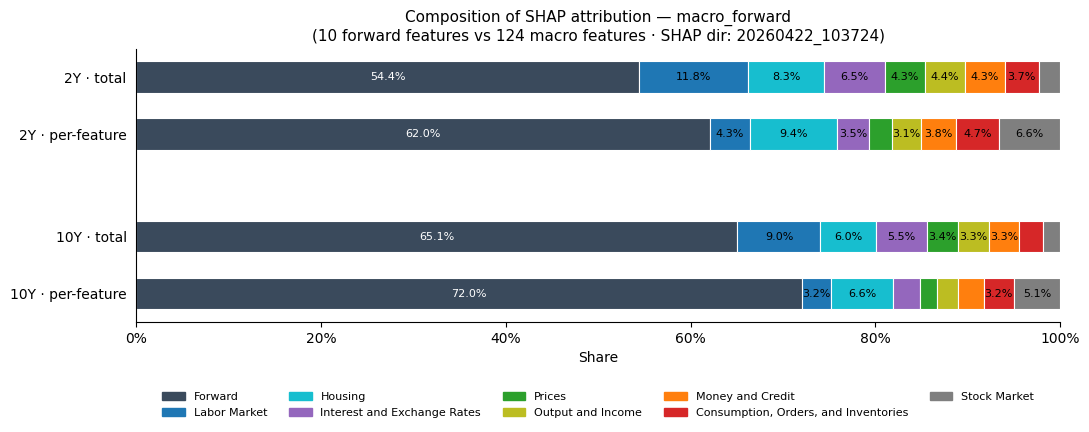


=== macro_forward · 24M ·  share of attribution (two views) ===
                                      share_total_%  share_per_feat_%  n_features
block                                                                            
forward                                       54.41             62.04          10
Labor Market                                  11.77              4.33          31
Housing                                        8.28              9.44          10
Interest and Exchange Rates                    6.52              3.54          21
Prices                                         4.33              2.47          20
Output and Income                              4.36              3.11          16
Money and Credit                               4.33              3.80          13
Consumption, Orders, and Inventories           3.68              4.66           9
Stock Market                                   2.32              6.61           4

=== macro_forward · 120M ·  shar

In [104]:
# ── Tier 1 knobs ──────────────────────────────────────────────────────────
tier1_model = 'macro_forward'        # 'macro_forward' | 'group_ensemble'
tier1_maturities = ['24', '120']     # 2-year and 10-year benchmarks
tier1_label_min_pct = 3.0            # hide segment labels smaller than this
# ──────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_tier1_runs = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}
if tier1_model not in _tier1_runs:
    raise KeyError(f'{tier1_model!r} not in {list(_tier1_runs)}')

_shap_root_t1 = REPO_ROOT / 'artifacts' / 'shap' / _tier1_runs[tier1_model]
_latest_dir_t1 = sorted(p for p in _shap_root_t1.iterdir() if p.is_dir())[-1]
sm_t1 = pd.read_parquet(_latest_dir_t1 / 'shap_mean.parquet')


def _parse_feature_t1(feat: str) -> str:
    """Return the block label: 'forward' or the FRED-MD group name."""
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    if len(parts) >= 2:
        return parts[0]
    return parts[0]


sm_t1 = sm_t1.assign(block=sm_t1['feature'].map(_parse_feature_t1))

# Two block-level aggregations — displayed as two stacked bars per maturity.
#
# (A) "total":    share of total attribution mass.
#     For each date, sum |SHAP| across features in the block; then average
#     those per-date totals across dates. Answers "where does the model's
#     total explanation come from on a typical date?"
#
# (B) "per_feat": share of per-feature intensity.
#     Mean |SHAP| across (date × feature) inside the block. Answers "how
#     much does a typical feature in this block contribute?", which removes
#     the feature-count effect that helps multi-series blocks in (A).
#
# Feature counts are very unequal: forwards have ~10 features while the
# macro block has ~120. (A) therefore looks more balanced than (B) does,
# and showing both keeps the headline honest.
agg_total = (
    sm_t1
    .groupby(['date', 'maturity', 'block'])['abs_mean_shap'].sum()
    .groupby(['maturity', 'block']).mean()
    .reset_index(name='value')
    .assign(agg='total')
)
agg_per_feat = (
    sm_t1
    .groupby(['maturity', 'block'])['abs_mean_shap'].mean()
    .reset_index(name='value')
    .assign(agg='per_feat')
)
agg_t1 = pd.concat([agg_total, agg_per_feat], ignore_index=True)

# Feature counts for the legend / summary line.
block_n_features = sm_t1.groupby('block')['feature'].nunique().to_dict()

# Establish a single block ordering for all bars: forward first (anchor
# colour), then macro groups in descending order of their total attribution
# across the selected maturities. Using the 'total' aggregation to set the
# ordering is the conservative choice.
macro_totals = (
    agg_t1[
        (agg_t1['block'] != 'forward')
        & (agg_t1['maturity'].isin(tier1_maturities))
        & (agg_t1['agg'] == 'total')
    ]
    .groupby('block')['value'].sum()
    .sort_values(ascending=False)
)
block_order = ['forward'] + list(macro_totals.index)

# Colours: forward is a neutral dark grey/steel so it doesn't compete with
# the macro palette. Macro groups reuse the blue-first palette from Tier 2
# (largest group is blue, decreasing in warmth from there).
_macro_palette = [
    '#1f77b4', '#17becf', '#9467bd', '#2ca02c',
    '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
]
block_colors = {'forward': '#3a4a5c'}
for i, g in enumerate(macro_totals.index):
    block_colors[g] = _macro_palette[i % len(_macro_palette)]


def _stacked_row(ax, mat: str, agg_type: str, y: float):
    sub = (
        agg_t1[(agg_t1['maturity'] == mat) & (agg_t1['agg'] == agg_type)]
        .set_index('block')['value']
        .reindex(block_order).fillna(0.0)
    )
    total = float(sub.sum())
    if total == 0.0:
        ax.text(0.5, y, f'no data for {mat}M', ha='center', va='center')
        return
    shares = sub / total
    left = 0.0
    for block in block_order:
        w = shares.loc[block]
        if w <= 0:
            continue
        ax.barh(y, w, left=left, height=0.55,
                color=block_colors[block], edgecolor='white', linewidth=0.8)
        if w * 100 >= tier1_label_min_pct:
            ax.text(left + w / 2, y, f'{w * 100:.1f}%',
                    ha='center', va='center',
                    fontsize=8, color='white' if block == 'forward' else 'black')
        left += w


# Row layout (top-down): for each maturity, two rows — "total" then
# "per_feat", with a visible gap between maturities.
row_specs = []
y_cursor = 0.0
for i, mat in enumerate(tier1_maturities):
    if i > 0:
        y_cursor += 0.8                          # gap between maturities
    row_specs.append((y_cursor, mat, 'total',    f'{int(mat)//12}Y · total'))
    y_cursor += 1.0
    row_specs.append((y_cursor, mat, 'per_feat', f'{int(mat)//12}Y · per-feature'))
    y_cursor += 1.0

fig, ax = plt.subplots(figsize=(11, 1.0 + 0.9 * len(row_specs)))
for y, mat, agg_type, _ in row_specs:
    _stacked_row(ax, mat, agg_type, -y)          # negate so the first row sits on top

ax.set_yticks([-y for y, *_ in row_specs])
ax.set_yticklabels([lbl for *_, lbl in row_specs], fontsize=10)
ax.set_xlim(0, 1)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([f'{int(v * 100)}%' for v in np.linspace(0, 1, 6)])
ax.set_xlabel('Share')
n_fwd = block_n_features.get('forward', 0)
n_mac = sum(v for k, v in block_n_features.items() if k != 'forward')
ax.set_title(
    f'Composition of SHAP attribution — {tier1_model}\n'
    f'({n_fwd} forward features vs {n_mac} macro features · SHAP dir: {_latest_dir_t1.name})',
    fontsize=11,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=False)

# Legend: forward then macro groups in blue-first order.
handles = [plt.Rectangle((0, 0), 1, 1, color=block_colors[b]) for b in block_order]
labels = [b.capitalize() if b == 'forward' else b for b in block_order]
ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=min(len(block_order), 5), frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

# Printable shares, both aggregations side-by-side.
for mat in tier1_maturities:
    rows = {}
    for agg_type in ('total', 'per_feat'):
        sub = (
            agg_t1[(agg_t1['maturity'] == mat) & (agg_t1['agg'] == agg_type)]
            .set_index('block')['value']
            .reindex(block_order).fillna(0.0)
        )
        tot = float(sub.sum())
        rows[f'share_{agg_type}_%'] = (sub / tot * 100) if tot > 0 else sub * 0
    combined = pd.DataFrame(rows)
    combined['n_features'] = pd.Series(block_n_features).reindex(block_order).fillna(0).astype(int)
    print(f'\n=== {tier1_model} · {mat}M ·  share of attribution (two views) ===')
    print(combined.round(2).to_string())

## Tier 1c — Block-averaged SHAP importance (one bar per forward / macro group)

Same ranked-bar format as Tier 1b, but instead of one bar per feature we collapse each block to one bar by averaging the per-feature mean $|\text{SHAP}|$ across the features inside the block:

\[
\text{importance}(\text{block}) \;=\; \frac{1}{|F_\text{block}|}\sum_{f\in F_\text{block}} \frac{1}{T}\sum_{t=1}^{T} \bigl|\overline{\text{SHAP}}_{t,f}\bigr|.
\]

Read it as *"how much does a typical feature inside this block contribute?"* — i.e. per-feature intensity by block. The forward block becomes one bar ("typical forward"), and each of the eight FRED-MD groups becomes one bar ("typical labour-market series", "typical housing series", …). This removes the feature-count effect that distorts the stacked total-share view (forwards: ~10 features; macro block: ~120 features). If you want the *summed* block totals instead — equivalent to the "total" stacked bar in Tier 1 but rendered as a ranked bar — flip `tier1c_agg` to `'sum'`.

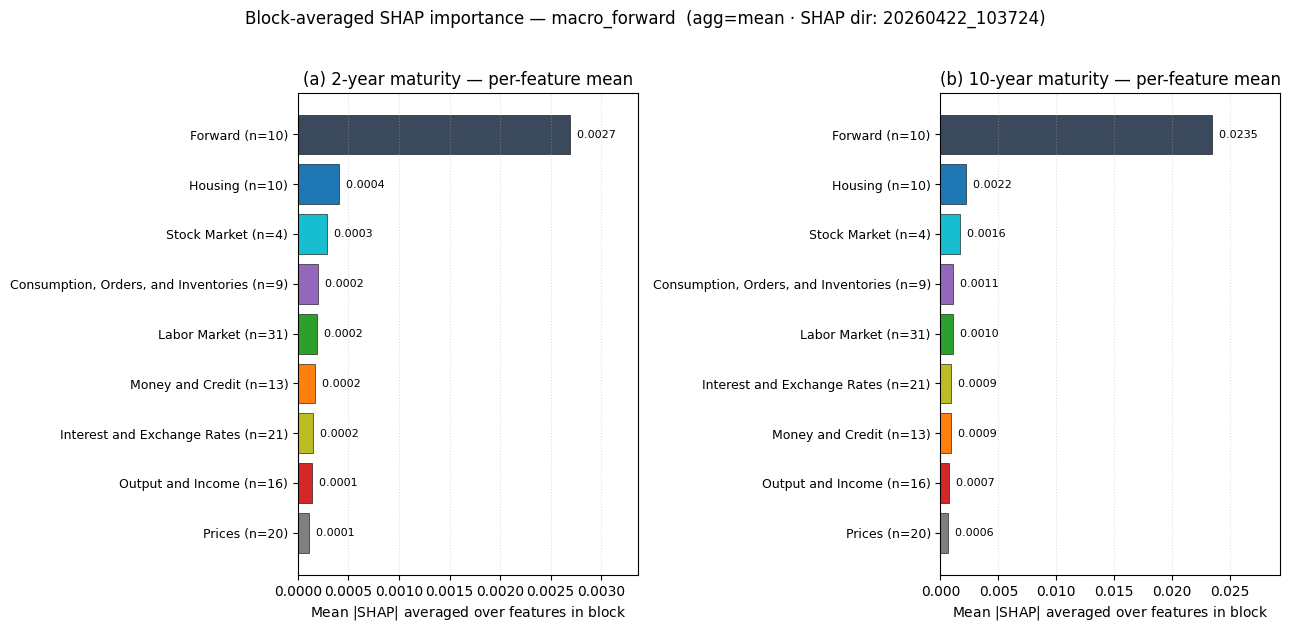


=== macro_forward · 24M · block importance (agg=mean) ===
                               block  n_features  importance  share_%
                             forward          10      0.0027  62.0435
                             Housing          10      0.0004   9.4424
                        Stock Market           4      0.0003   6.6126
Consumption, Orders, and Inventories           9      0.0002   4.6590
                        Labor Market          31      0.0002   4.3283
                    Money and Credit          13      0.0002   3.7963
         Interest and Exchange Rates          21      0.0002   3.5377
                   Output and Income          16      0.0001   3.1099
                              Prices          20      0.0001   2.4703

=== macro_forward · 120M · block importance (agg=mean) ===
                               block  n_features  importance  share_%
                             forward          10      0.0235  72.0061
                             Housing     

In [106]:
# ── Tier 1c knobs ─────────────────────────────────────────────────────────
tier1c_model = 'macro_forward'        # 'macro_forward' | 'group_ensemble'
tier1c_maturities = ['24', '120']     # 2-year and 10-year benchmarks
tier1c_agg = 'mean'                   # 'mean' (per-feature intensity) | 'sum' (total mass)
# ──────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_tier1c_runs = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}
if tier1c_model not in _tier1c_runs:
    raise KeyError(f'{tier1c_model!r} not in {list(_tier1c_runs)}')
if tier1c_agg not in ('mean', 'sum'):
    raise ValueError(f"tier1c_agg must be 'mean' or 'sum', got {tier1c_agg!r}")

_shap_root_t1c = REPO_ROOT / 'artifacts' / 'shap' / _tier1c_runs[tier1c_model]
_latest_dir_t1c = sorted(p for p in _shap_root_t1c.iterdir() if p.is_dir())[-1]
sm_t1c = pd.read_parquet(_latest_dir_t1c / 'shap_mean.parquet')


def _parse_block_t1c(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    if len(parts) >= 2:
        return parts[0]
    return parts[0]


sm_t1c = sm_t1c.assign(block=sm_t1c['feature'].map(_parse_block_t1c))

# Per-feature mean |SHAP| across dates, then aggregate features within the block.
_per_feat = (
    sm_t1c
    .groupby(['maturity', 'block', 'feature'])['abs_mean_shap']
    .mean()                                   # mean across dates per feature
    .reset_index(name='per_feat_importance')
)
if tier1c_agg == 'mean':
    imp_t1c = (
        _per_feat.groupby(['maturity', 'block'])['per_feat_importance']
        .mean().reset_index(name='importance')
    )
    x_label = r'Mean $|\mathrm{SHAP}|$ averaged over features in block'
    agg_tag = 'per-feature mean'
else:  # 'sum'
    imp_t1c = (
        _per_feat.groupby(['maturity', 'block'])['per_feat_importance']
        .sum().reset_index(name='importance')
    )
    x_label = r'Summed mean $|\mathrm{SHAP}|$ over features in block'
    agg_tag = 'block total'

# Feature counts for the table / annotations.
block_n_t1c = sm_t1c.groupby('block')['feature'].nunique().to_dict()

# Colour scheme: forward grey, macro groups blue-first by summed importance.
_classic_blue_first_t1c = [
    '#1f77b4', '#17becf', '#9467bd', '#2ca02c',
    '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
    '#8c564b', '#c5b0d5',
]
_macro_order_t1c = (
    imp_t1c[(imp_t1c['block'] != 'forward')
            & (imp_t1c['maturity'].isin(tier1c_maturities))]
    .groupby('block')['importance'].sum()
    .sort_values(ascending=False)
    .index.tolist()
)
block_colors_t1c = {'forward': '#3a4a5c'}
for i, g in enumerate(_macro_order_t1c):
    block_colors_t1c[g] = _classic_blue_first_t1c[i % len(_classic_blue_first_t1c)]


def _panel_t1c(ax, mat: str, label_prefix: str):
    sub = imp_t1c[imp_t1c['maturity'] == mat].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'no data for {mat}M', ha='center', va='center')
        ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity')
        ax.axis('off')
        return
    sub = sub.sort_values('importance', ascending=True)     # largest at top
    sub['label'] = sub['block'].map(
        lambda b: f'{b.capitalize() if b == "forward" else b} '
                  f'(n={block_n_t1c.get(b, 0)})'
    )
    colors = [block_colors_t1c.get(b, '#999999') for b in sub['block']]
    ax.barh(sub['label'], sub['importance'], color=colors,
            edgecolor='black', linewidth=0.4)
    for y, v in zip(sub['label'], sub['importance']):
        ax.text(v, y, f'  {v:.4f}', va='center', fontsize=8)
    ax.set_xlabel(x_label)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity — {agg_tag}')
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    # Leave room on the right for the value annotation.
    ax.set_xlim(0, sub['importance'].max() * 1.25)


fig, axes = plt.subplots(
    1, len(tier1c_maturities),
    figsize=(6.5 * len(tier1c_maturities),
             0.55 * max(3, len(_macro_order_t1c) + 1) + 1.2),
    sharex=False,
)
if len(tier1c_maturities) == 1:
    axes = [axes]
for ax, mat, lbl in zip(axes, tier1c_maturities, ['(a)', '(b)', '(c)', '(d)']):
    _panel_t1c(ax, mat, lbl)

fig.suptitle(
    f'Block-averaged SHAP importance — {tier1c_model}  '
    f'(agg={tier1c_agg} · SHAP dir: {_latest_dir_t1c.name})',
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.show()

# Printable tables.
for mat in tier1c_maturities:
    sub = imp_t1c[imp_t1c['maturity'] == mat].copy()
    if sub.empty:
        print(f'\n=== {tier1c_model} · {mat}M · no data ===')
        continue
    sub = sub.sort_values('importance', ascending=False)
    sub['n_features'] = sub['block'].map(block_n_t1c).fillna(0).astype(int)
    sub['share_%'] = sub['importance'] / sub['importance'].sum() * 100
    print(f'\n=== {tier1c_model} · {mat}M · block importance (agg={tier1c_agg}) ===')
    print(sub[['block', 'n_features', 'importance', 'share_%']]
          .round(4).to_string(index=False))


## Tier 2 — Bianchi-style macro importance at selected maturities

Reproduces the four-panel layout used by Bianchi, Büchner, Tamoni (2021) for a single model: top row = top-N individual macro features ranked by relative importance (mean |SHAP|, rescaled so the most important = 1.0), bottom row = pie chart of macro attribution by FRED-MD group. Left column is the short end (24 months), right column is the long end (120 months). Forwards are excluded from both the bars and the pies so the figure is a pure view into "where inside the macro block does attribution concentrate". Switch `tier2_model` between `'macro_forward'` and `'group_ensemble'` and re-run — everything downstream of the SHAP parquet is model-agnostic.

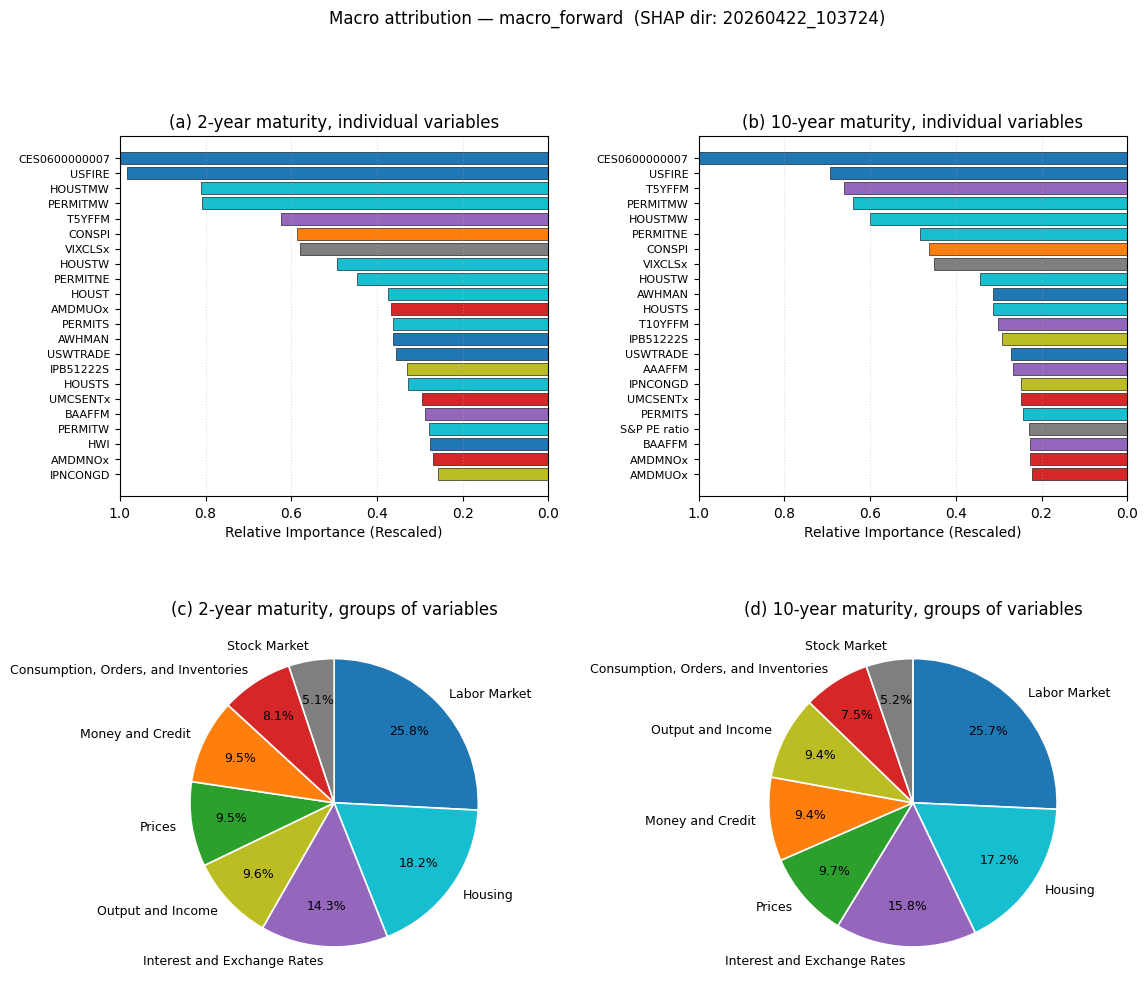


=== macro_forward · 24M · top 22 macro features ===
       series                                group  abs_mean_shap    rel
CES0600000007                         Labor Market         0.0010 1.0000
       USFIRE                         Labor Market         0.0009 0.9841
      HOUSTMW                              Housing         0.0008 0.8094
     PERMITMW                              Housing         0.0008 0.8081
       T5YFFM          Interest and Exchange Rates         0.0006 0.6249
       CONSPI                     Money and Credit         0.0006 0.5861
      VIXCLSx                         Stock Market         0.0006 0.5797
       HOUSTW                              Housing         0.0005 0.4931
     PERMITNE                              Housing         0.0004 0.4461
        HOUST                              Housing         0.0004 0.3732
      AMDMUOx Consumption, Orders, and Inventories         0.0004 0.3679
      PERMITS                              Housing         0.0003 0.363

In [107]:
# ── Tier 2 knobs ──────────────────────────────────────────────────────────
tier2_model = 'macro_forward'          # 'macro_forward' | 'group_ensemble'
tier2_maturities = ['24', '120']       # (short end, long end); paper uses 2Y & 10Y
tier2_top_n = 22                        # number of features in the bar charts
tier2_normalize = 'max'                 # 'max' (paper, top bar = 1.0) | 'sum' (shares, adds to 100%) | 'raw' (absolute mean |SHAP|)
# ──────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_tier2_runs = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}
if tier2_model not in _tier2_runs:
    raise KeyError(f'{tier2_model!r} not in {list(_tier2_runs)}')

_shap_root = REPO_ROOT / 'artifacts' / 'shap' / _tier2_runs[tier2_model]
_latest_dir = sorted(p for p in _shap_root.iterdir() if p.is_dir())[-1]
sm = pd.read_parquet(_latest_dir / 'shap_mean.parquet')


def _parse_feature(feat: str):
    """Return (group, series) for both macro_forward and group_ensemble naming.

    - forward features    : ('forward', '<n>')
    - macro_forward macro : 'fred::<group>::<series>'         -> (group, series)
    - group_ensemble macro: '<group>::<series>'               -> (group, series)
    """
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward', parts[-1]
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1], parts[2]
    if len(parts) >= 2:
        return parts[0], parts[1]
    return parts[0], feat


parsed = sm['feature'].map(_parse_feature)
sm = sm.assign(group=parsed.map(lambda t: t[0]),
               series=parsed.map(lambda t: t[1]))
sm_macro = sm[sm['group'] != 'forward'].copy()

# Rank: average mean |SHAP| over dates, per (maturity, feature).
agg = (
    sm_macro.groupby(['maturity', 'feature', 'group', 'series'])['abs_mean_shap']
    .mean()
    .reset_index()
)

# Consistent colour per group across both the bars and the pies.
# Using Tableau-10 (a desaturated but still distinct palette) — calmer than
# matplotlib's 'tab10' and more readable than the 'Set2' / 'Pastel2' pastels.
# Classic matplotlib palette, reordered so the biggest macro groups get the
# cool (bluer) colours and the smallest groups end up with warm ones.
# Group ordering is by total mean |SHAP| summed over the selected maturities,
# so the "biggest → bluest" assignment is consistent across all four panels.
_classic_blue_first = [
    '#1f77b4',   # tab:blue
    '#17becf',   # tab:cyan
    '#9467bd',   # tab:purple
    '#2ca02c',   # tab:green
    '#bcbd22',   # tab:olive
    '#ff7f0e',   # tab:orange
    '#d62728',   # tab:red
    '#7f7f7f',   # tab:gray
    '#8c564b',   # tab:brown   (overflow)
    '#c5b0d5',   # soft lilac  (overflow)
]
_group_totals = (
    sm_macro[sm_macro['maturity'].isin(tier2_maturities)]
    .groupby('group')['abs_mean_shap'].sum()
    .sort_values(ascending=False)
)
all_groups = list(_group_totals.index)
group_colors = {g: _classic_blue_first[i % len(_classic_blue_first)]
                for i, g in enumerate(all_groups)}


def _panel_bars(ax, mat: str, label_prefix: str):
    sub = agg[agg['maturity'] == mat].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'no data for {mat}M', ha='center', va='center')
        ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity, individual variables')
        ax.axis('off')
        return
    sub = sub.nlargest(tier2_top_n, 'abs_mean_shap').copy()
    sub['rel'] = sub['abs_mean_shap'] / sub['abs_mean_shap'].max()
    sub = sub.sort_values('rel', ascending=True)   # largest at top of the barh
    colors = [group_colors[g] for g in sub['group']]
    ax.barh(sub['series'], sub['rel'], color=colors, edgecolor='black', linewidth=0.4)
    ax.set_xlim(1.0, 0.0)                          # decreasing left→right like the paper
    ax.set_xlabel('Relative Importance (Rescaled)')
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity, individual variables')
    ax.grid(axis='x', linestyle=':', alpha=0.4)


def _panel_pie(ax, mat: str, label_prefix: str):
    sub = sm_macro[sm_macro['maturity'] == mat]
    if sub.empty:
        ax.text(0.5, 0.5, f'no data for {mat}M', ha='center', va='center')
        ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity, groups of variables')
        ax.axis('off')
        return
    by_group = sub.groupby('group')['abs_mean_shap'].sum().sort_values(ascending=False)
    colors = [group_colors[g] for g in by_group.index]

    def _fmt_pct(p: float) -> str:
        # Hide labels for tiny slivers to keep the chart readable.
        return f'{p:.1f}%' if p >= 3.0 else ''

    ax.pie(
        by_group.values,
        labels=by_group.index,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=_fmt_pct,
        pctdistance=0.72,
        wedgeprops=dict(edgecolor='white', linewidth=1.2),
        textprops=dict(fontsize=9),
    )
    ax.set_title(f'{label_prefix} {int(mat)//12}-year maturity, groups of variables')


fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)
mats = list(tier2_maturities)
labels = ['(a)', '(b)', '(c)', '(d)']
_panel_bars(fig.add_subplot(gs[0, 0]), mats[0], labels[0])
_panel_bars(fig.add_subplot(gs[0, 1]), mats[1], labels[1])
_panel_pie (fig.add_subplot(gs[1, 0]), mats[0], labels[2])
_panel_pie (fig.add_subplot(gs[1, 1]), mats[1], labels[3])
fig.suptitle(
    f'Macro attribution — {tier2_model}  (SHAP dir: {_latest_dir.name})',
    y=0.995, fontsize=12,
)
plt.show()

# Printable tables for the bar panels.
for mat in mats:
    sub = agg[agg['maturity'] == mat].nlargest(tier2_top_n, 'abs_mean_shap').copy()
    if sub.empty:
        print(f'\n=== {tier2_model} · {mat}M · top {tier2_top_n} macro features ===')
        print('  (no data)')
        continue
    sub['rel'] = sub['abs_mean_shap'] / sub['abs_mean_shap'].max()
    print(f'\n=== {tier2_model} · {mat}M · top {tier2_top_n} macro features ===')
    print(
        sub[['series', 'group', 'abs_mean_shap', 'rel']]
        .round(4).to_string(index=False)
    )

**Interpretation.** Panels (a) and (b) rank the individual FRED-MD series the model relies on most at the 2-year and 10-year maturities, using the time-averaged mean |SHAP| and rescaling each panel so the most important feature equals 1. Wedge colours match between the bars and the pies, so a series's colour tells you which FRED-MD theme it belongs to, and panels (c) and (d) aggregate those shares into the eight groups. Forwards are excluded throughout — otherwise the forward block would dominate and flatten everything macro, so this figure is specifically a look *inside* the macro block. Two things to read off the figure: first, the group composition of the pies (c vs d) tells you how the model's macro reliance rotates across the term structure — typically labour-market and housing series anchor the short end, while interest-and-exchange-rate series gain share at the long end, consistent with a real-activity-vs-monetary-policy split across horizons. Second, the individual bars (a, b) tell you *which* series within each group drive the ranking; if the same series appear in both panels, the model's macro signal is term-structure-stable, and if the top names change markedly between 2Y and 10Y, the model is learning horizon-specific macro information that forwards alone would not capture. Because the bars are rescaled per panel (the convention in Bianchi–Büchner–Tamoni 2021), absolute levels are not comparable across (a) and (b); use `tier2_normalize='raw'` if you need absolute |SHAP| or `'sum'` for within-panel shares.

## Tier 5 — Seed-to-seed stability & additivity

SHAP values are noisy: DeepExplainer's attribution depends on the sampled background, and the per-model ensemble averages over only `k_top=2` seeds. It's worth checking whether the top-ranked features are robust to seed choice before any narrative is built on them.

These plots read `per_seed_shap.parquet` and `per_seed_meta.parquet` from each run's SHAP output directory. They were produced because `save_per_seed=True` was set in the config above — if you ran an older sweep without that flag, re-run it with the flag on.

**Why we filter out forward rates.** Forward rates mechanically explain most of bond-return variation, so they dominate any raw top-k ranking (typically ~70% of total mean |SHAP|). We acknowledge that once in section 5.1b with a forward-vs-macro bar, then every feature-level plot from 5.2 onward uses `macro_only=True` so macro features can be seen. Flip the flag in each cell to include forwards.

Five views per run:

1. **Additivity residual over time** — per-(date, maturity, seed) residual of `pred - (base + Σ shap)`. Should be at the floating-point floor (~1e-6 or better in scaled space). Spikes flag numerical instability.
2. **Forward vs macro share** — table + bar showing how much of total |SHAP| each block carries per maturity. Acknowledges the forward dominance, then we move on.
3. **Per-seed signed SHAP boxplot** (macro only) — wide boxes = noisy attributions.
4. **Coefficient of variation** (macro only) — `std_shap / |mean_shap|` averaged over time. Features with CoV > 1 are essentially indistinguishable from seed noise.
5. **Rank agreement between seeds** (macro only) — Spearman correlation between per-seed feature rankings. Low correlation = different seeds see different "important" features.

In [108]:
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

shap_output_root = REPO_ROOT / 'artifacts' / 'shap'

def latest_shap_dir(run_name):
    """Find the most recent SHAP output directory for a given run_name."""
    root = shap_output_root / run_name
    if not root.exists():
        raise FileNotFoundError(
            f'No SHAP output for {run_name!r}. Re-run the compute cell first.'
        )
    stamps = sorted([p for p in root.iterdir() if p.is_dir()])
    if not stamps:
        raise FileNotFoundError(f'No timestamped SHAP runs under {root}')
    return stamps[-1]

def load_shap_tier5(run_name):
    """Return (per_seed_meta, per_seed_shap, shap_mean, shap_std, meta) DataFrames
    for a SHAP run, or raise a helpful error if per-seed artifacts are missing."""
    d = latest_shap_dir(run_name)
    per_seed_meta_path = d / 'per_seed_meta.parquet'
    per_seed_shap_path = d / 'per_seed_shap.parquet'
    if not per_seed_meta_path.exists() or not per_seed_shap_path.exists():
        raise FileNotFoundError(
            f'Per-seed artifacts missing under {d}. '
            f'Re-run the SHAP compute with save_per_seed=True.'
        )
    psm = pd.read_parquet(per_seed_meta_path)
    pss = pd.read_parquet(per_seed_shap_path)
    sm = pd.read_parquet(d / 'shap_mean.parquet')
    sd = pd.read_parquet(d / 'shap_std.parquet')
    psm['date'] = pd.to_datetime(psm['date'])
    pss['date'] = pd.to_datetime(pss['date'])
    sm['date'] = pd.to_datetime(sm['date'])
    sd['date'] = pd.to_datetime(sd['date'])
    return psm, pss, sm, sd, d

tier5_runs = {
    'macro_forward': 'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}
tier5_data = {k: load_shap_tier5(rn) for k, rn in tier5_runs.items()}

def is_forward(feature: str) -> bool:
    """True for forward-rate features. Everything else is 'macro' (FRED-MD)."""
    return feature.startswith('forward::')

def macro_mask(df, col='feature'):
    """Boolean mask: True for macro features (drops forward rates)."""
    return ~df[col].map(is_forward)

for k, (psm, pss, sm, sd, out_dir) in tier5_data.items():
    n_fwd = sm[~macro_mask(sm)]['feature'].nunique()
    n_mac = sm[macro_mask(sm)]['feature'].nunique()
    print(
        f'{k:14s} dates={psm["date"].nunique():4d} '
        f'maturities={sorted(psm["maturity"].unique())}  '
        f'seeds/row={psm.groupby(["date","maturity"])["seed"].nunique().max()}  '
        f'features={sm["feature"].nunique()} (fwd={n_fwd}, macro={n_mac})  '
        f'dir={out_dir.name}'
    )

macro_forward  dates= 336 maturities=['120', '24', '36', '48', '60', '84']  seeds/row=2  features=134 (fwd=10, macro=124)  dir=20260422_103724
group_ensemble dates= 336 maturities=['120', '24', '36', '48', '60', '84']  seeds/row=2  features=134 (fwd=10, macro=124)  dir=20260422_104101


### 5.2 — Per-seed signed SHAP for top features (boxplots)

For the top-k features by mean |SHAP| (picked from the ensemble average), show the distribution of raw per-seed signed SHAP across all (date, seed) pairs at one maturity. Wide boxes relative to the median = the ensemble average is masking significant seed-to-seed disagreement.

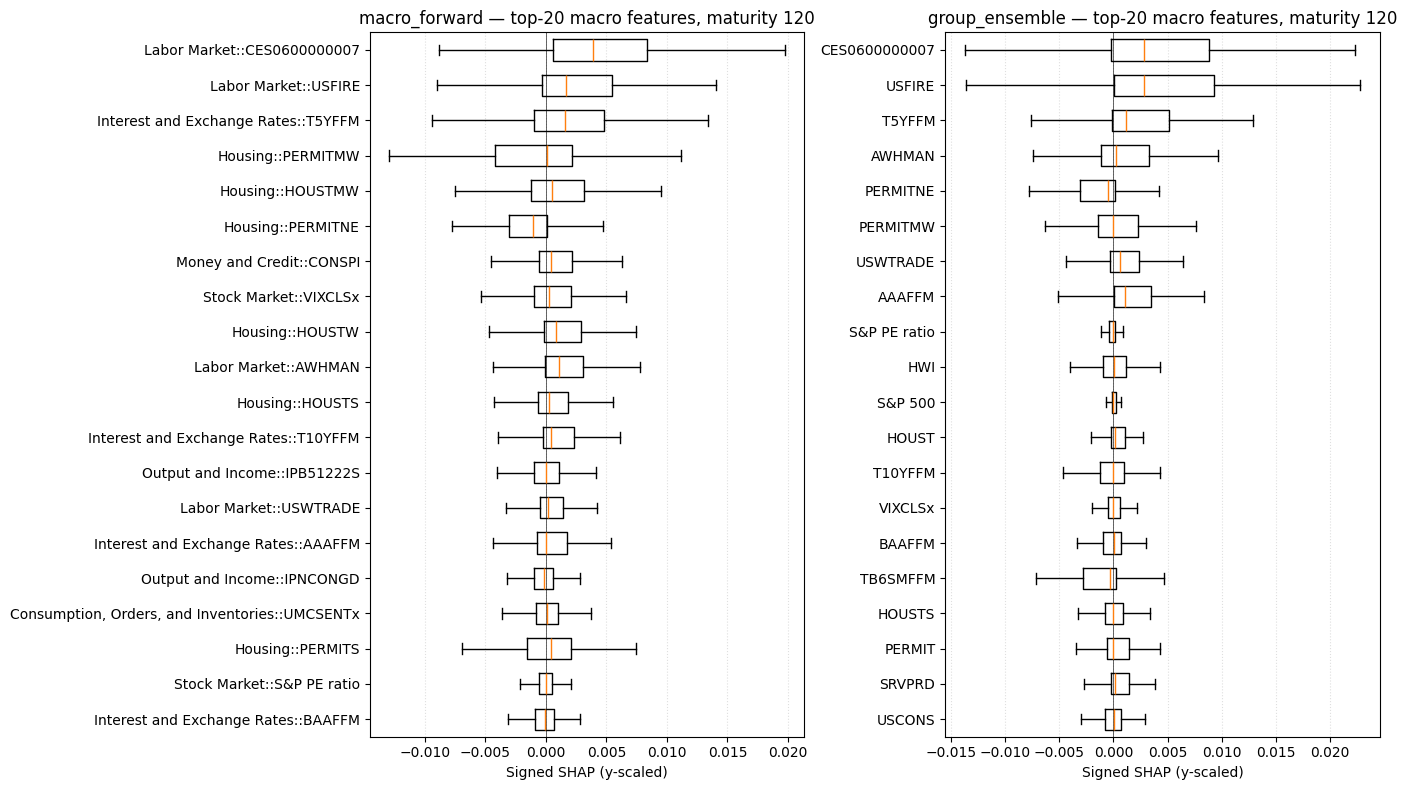

In [111]:
plot_maturity = '120'
top_k = 20
macro_only = True  # flip to False if you actually want forwards in the ranking

fig, axes = plt.subplots(
    1, len(tier5_data), figsize=(7 * len(tier5_data), 8), squeeze=False,
)
for ax, (name, (_, pss, sm, _, _)) in zip(axes[0], tier5_data.items()):
    sm_m = sm[sm['maturity'] == plot_maturity]
    if macro_only:
        sm_m = sm_m[macro_mask(sm_m)]
    top_features = (
        sm_m.groupby('feature')['abs_mean_shap']
        .mean().sort_values(ascending=False).head(top_k).index.tolist()
    )
    pss_m = pss[(pss['maturity'] == plot_maturity) & (pss['feature'].isin(top_features))]
    box_data = [pss_m.loc[pss_m['feature'] == f, 'shap_value'].values for f in top_features]
    labels = [f.split('::', 1)[-1] for f in top_features]
    try:
        ax.boxplot(box_data, vert=False, tick_labels=labels, showfliers=False, widths=0.6)
    except TypeError:
        ax.boxplot(box_data, vert=False, labels=labels, showfliers=False, widths=0.6)
    ax.axvline(0, color='black', lw=0.6, alpha=0.7)
    ax.set_xlabel('Signed SHAP (y-scaled)')
    scope = 'macro' if macro_only else 'all'
    ax.set_title(f'{name} — top-{top_k} {scope} features, maturity {plot_maturity}')
    ax.invert_yaxis()
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)
fig.tight_layout()
plt.show()

## Tier 6 — Group-level attribution (both models, apples-to-apples)

SHAP attributes to model *inputs*, so the raw output is per-feature for both the single-tower `MacroForwardANNWrapper` and the per-group `GroupEnsembleANNWrapper`. At the individual-feature level most macros are noisy (Tier 5 showed that 100+ of 124 features have CoV > 1) — but aggregating to the 8 FRED-MD groups averages out most of that noise and matches the architectural atomic unit of the group-ensemble model.

Since both models share the same feature set and the same FRED-MD grouping, group-level mean |SHAP| is directly comparable across them. Forwards are kept as a single `forward` block for context.

Three views:

1. **Mean |SHAP| per group, per maturity** — grouped bar, one panel per model. Shows which macro themes each architecture leans on across the term structure.
2. **Group attribution over time** — stacked-area per maturity, so we can see whether e.g. Housing's contribution drifts over the sample.
3. **Cross-model agreement** — scatter of per-(group, maturity) mean |SHAP| in `macro_forward` vs `group_ensemble`. Points near the diagonal ⇒ both architectures agree.

In [114]:
def feature_group(feature: str) -> str:
    """Derive FRED-MD group (or 'forward') from a feature name.

    macro_forward uses ``fred::<group>::<series>``; group_ensemble uses
    ``<group>::<series>``. Forward rates use ``forward::...`` in both.
    """
    parts = feature.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    return parts[0]

def group_level_mean_abs(sm: pd.DataFrame) -> pd.DataFrame:
    """(date × maturity × group) mean |SHAP|, summed over features in each group."""
    df = sm.assign(group=sm['feature'].map(feature_group))
    return (
        df.groupby(['date', 'maturity', 'group'])['abs_mean_shap']
        .sum()
        .reset_index(name='group_abs_shap')
    )

def group_level_time_averaged(sm: pd.DataFrame) -> pd.DataFrame:
    """Time-averaged per-(maturity, group) mean |SHAP| — for bar charts & scatter."""
    g = group_level_mean_abs(sm)
    return (
        g.groupby(['maturity', 'group'])['group_abs_shap']
        .mean()
        .reset_index()
    )

macro_group_order = [
    'Output and Income',
    'Labor Market',
    'Housing',
    'Consumption, Orders, and Inventories',
    'Money and Credit',
    'Interest and Exchange Rates',
    'Prices',
    'Stock Market',
]
block_order = ['forward'] + macro_group_order

tier6 = {
    name: {
        'time': group_level_mean_abs(sm),
        'avg': group_level_time_averaged(sm),
    }
    for name, (_, _, sm, _, _) in tier5_data.items()
}

for name, d in tier6.items():
    avg = d['avg']
    n_mat = avg['maturity'].nunique()
    observed = sorted(avg['group'].unique())
    unknown = [g for g in observed if g not in block_order]
    if unknown:
        print(f'{name}: WARNING — unexpected groups not in canonical order: {unknown}')
    print(f'{name}: maturities={n_mat}, groups={len(observed)}')

macro_forward: maturities=6, groups=9
group_ensemble: maturities=6, groups=9


### 6.1 — Mean |SHAP| per group, per maturity

Grouped bar chart. Rows = macro groups (+ forward), x-axis = maturity, one panel per model. Bars are mean |SHAP| over all OOS dates. The relative height *within* a maturity is what to read; absolute heights aren't comparable across models because y-scaling differs.

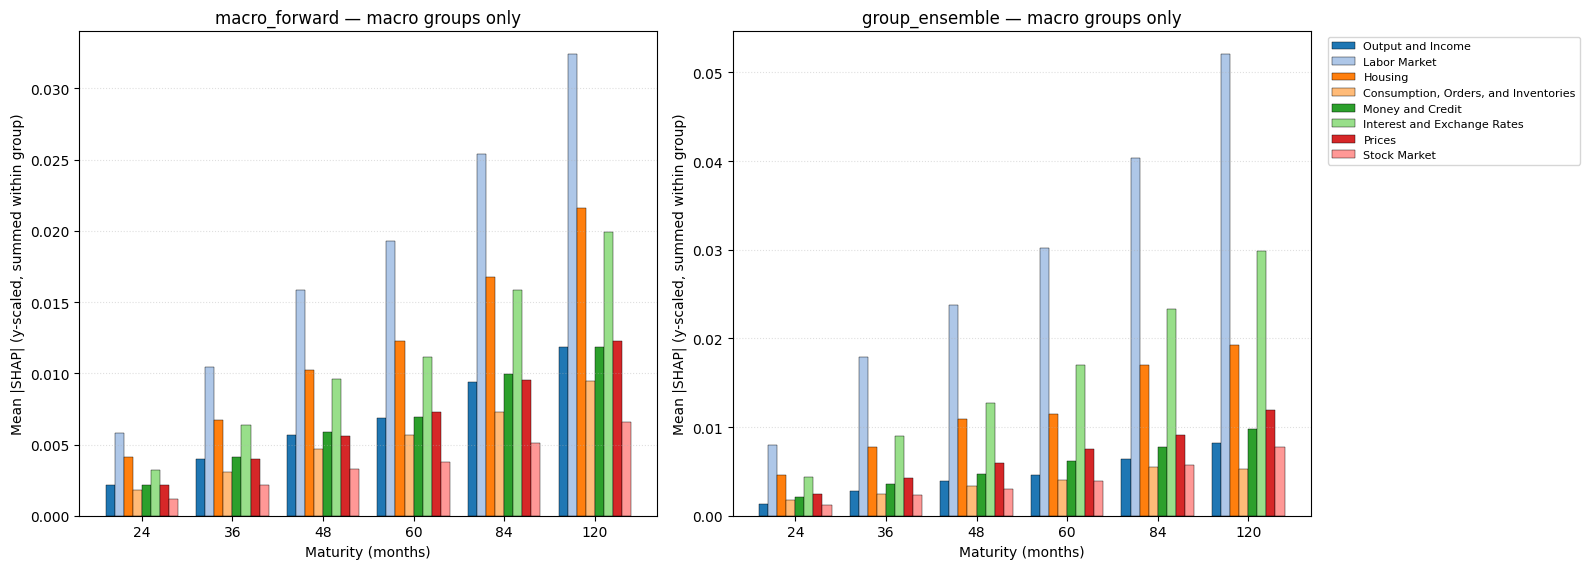

In [115]:
include_forward_6_1 = False  # forward dominates; uncheck to see the macro story on its own scale

fig, axes = plt.subplots(
    1, len(tier6), figsize=(8 * len(tier6), 5.8), squeeze=False, sharey=False,
)
cmap = plt.get_cmap('tab20')
row_order = block_order if include_forward_6_1 else macro_group_order
palette = {g: cmap(i % 20) for i, g in enumerate(row_order)}

for ax, (name, d) in zip(axes[0], tier6.items()):
    avg = d['avg']
    if not include_forward_6_1:
        avg = avg[avg['group'] != 'forward']
    maturities = sorted(avg['maturity'].unique(), key=lambda m: int(m))
    x = np.arange(len(maturities))
    n_groups = len(row_order)
    w = 0.8 / n_groups
    for i, g in enumerate(row_order):
        vals = [
            float(avg[(avg['maturity'] == m) & (avg['group'] == g)]['group_abs_shap'].sum())
            for m in maturities
        ]
        ax.bar(x + (i - (n_groups - 1) / 2) * w, vals, w,
               label=g, color=palette[g], edgecolor='black', lw=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(maturities)
    ax.set_xlabel('Maturity (months)')
    ax.set_ylabel('Mean |SHAP| (y-scaled, summed within group)')
    scope = 'incl. forward' if include_forward_6_1 else 'macro groups only'
    ax.set_title(f'{name} — {scope}')
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
axes[0][-1].legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

### 6.2 — Group attribution over time (stacked area)

Stacked-area chart of per-group mean |SHAP| over the OOS sample, one row per maturity (picks a sensible subset). A rising slice means that group's share of explanation is growing over time; shifting colors indicate regime-dependent attribution. Forward is excluded here so the macro groups are legible — include it if you want the absolute picture.

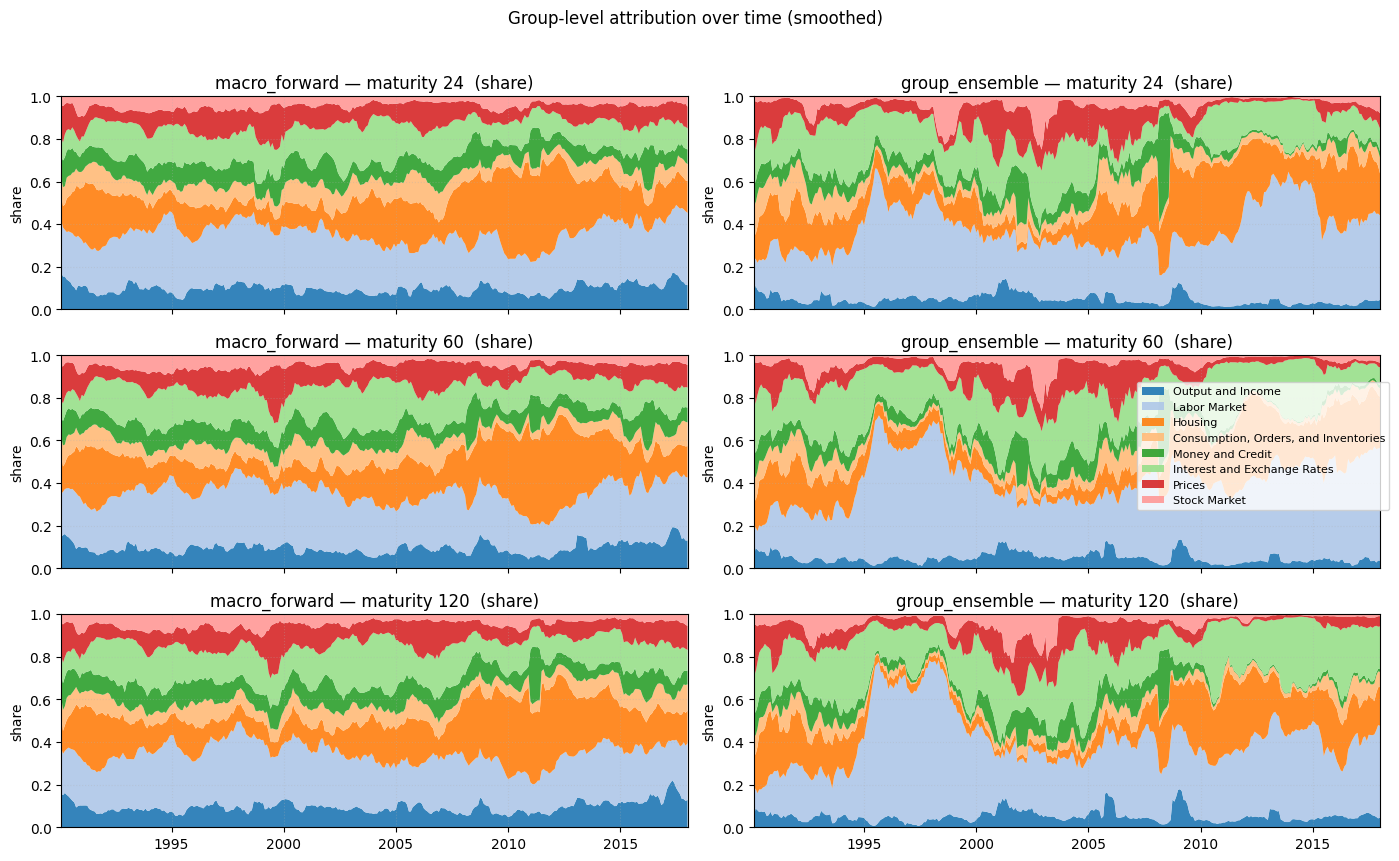

In [116]:
maturities_to_show = ['24', '60', '120']  # short / medium / long
include_forward_6_2 = False
normalise_to_share = True  # True = 0..1 share per date; False = absolute mean |SHAP|
smoothing_window = 6  # months; set to 1 to disable

rows = [m for m in maturities_to_show]
fig, axes = plt.subplots(
    len(rows), len(tier6), figsize=(7 * len(tier6), 2.8 * len(rows)),
    sharex=True, squeeze=False,
)
row_groups = macro_group_order if not include_forward_6_2 else block_order
colors = [palette[g] for g in row_groups]

for j, (name, d) in enumerate(tier6.items()):
    gdf = d['time'].copy()
    if not include_forward_6_2:
        gdf = gdf[gdf['group'] != 'forward']
    for i, m in enumerate(rows):
        ax = axes[i][j]
        sub = gdf[gdf['maturity'] == m]
        if sub.empty:
            ax.text(0.5, 0.5, f'no data for maturity {m}', ha='center', va='center')
            continue
        pivot = sub.pivot_table(
            index='date', columns='group', values='group_abs_shap', aggfunc='sum'
        ).fillna(0.0)
        # enforce column order for consistent colors
        pivot = pivot.reindex(columns=[g for g in row_groups if g in pivot.columns])
        if smoothing_window and smoothing_window > 1:
            pivot = pivot.rolling(smoothing_window, min_periods=1).mean()
        if normalise_to_share:
            totals = pivot.sum(axis=1).replace(0, np.nan)
            pivot = pivot.div(totals, axis=0).fillna(0.0)
        ax.stackplot(
            pivot.index, pivot.T.values,
            labels=list(pivot.columns),
            colors=[palette[c] for c in pivot.columns],
            alpha=0.9, linewidth=0.0,
        )
        ax.set_ylim(0, 1 if normalise_to_share else None)
        ax.set_title(f'{name} — maturity {m}' + ('  (share)' if normalise_to_share else ''))
        ax.set_ylabel('share' if normalise_to_share else '|SHAP|')
        ax.margins(x=0)
        ax.grid(True, linestyle=':', alpha=0.3)
        ax.xaxis.set_major_locator(YearLocator(5))
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))

# single legend to the right of the last panel
handles, labels = axes[0][-1].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='center right', bbox_to_anchor=(1.00, 0.5),
    fontsize=8, frameon=True,
)
fig.suptitle('Group-level attribution over time (smoothed)', y=1.02)
fig.tight_layout()
plt.show()

### 6.3 — Cross-model agreement at group level

For every (group, maturity), plot `macro_forward`'s time-averaged group |SHAP| on the x-axis vs `group_ensemble`'s on the y-axis. To make absolute magnitudes comparable, each model's values are normalised to sum to 1 within each maturity (so the plot reads "share of explanation allocated to each group"). Points on the diagonal ⇒ both architectures assign the same share to that group. Off-diagonal points are where the architectures disagree — those are the interpretation-sensitive groups.

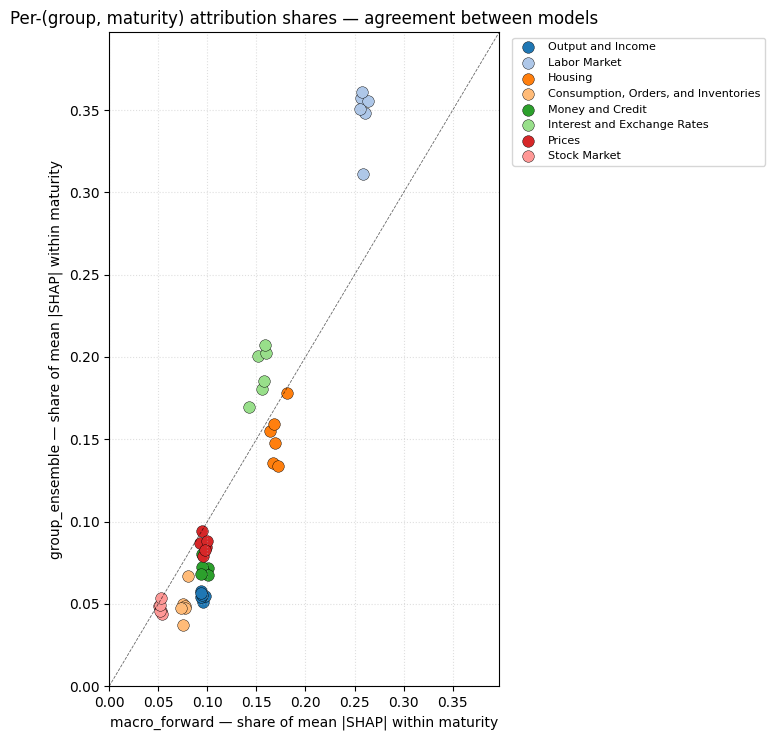

Per-group average disagreement (share of within-maturity attribution):
                                      mean_abs_share_diff  max_abs_share_diff  macro_forward_avg_share  group_ensemble_avg_share
group                                                                                                                           
Labor Market                                        0.089               0.104                    0.259                     0.347
Output and Income                                   0.040               0.045                    0.095                     0.055
Interest and Exchange Rates                         0.037               0.049                    0.154                     0.191
Consumption, Orders, and Inventories                0.027               0.038                    0.076                     0.050
Money and Credit                                    0.025               0.033                    0.097                     0.072
Housing                   

In [117]:
include_forward_6_3 = False

def group_shares_per_maturity(avg: pd.DataFrame, include_forward: bool) -> pd.DataFrame:
    """Return (group × maturity) share of mean |SHAP| within each maturity."""
    df = avg.copy()
    if not include_forward:
        df = df[df['group'] != 'forward']
    piv = df.pivot_table(
        index='group', columns='maturity', values='group_abs_shap', aggfunc='sum'
    ).fillna(0.0)
    return piv.div(piv.sum(axis=0), axis=1)

shares = {
    name: group_shares_per_maturity(d['avg'], include_forward_6_3)
    for name, d in tier6.items()
}
m_x = shares['macro_forward']
g_e = shares['group_ensemble']

common_groups = [g for g in (block_order if include_forward_6_3 else macro_group_order)
                 if g in m_x.index and g in g_e.index]
common_mats = sorted(set(m_x.columns).intersection(g_e.columns), key=lambda m: int(m))

fig, ax = plt.subplots(figsize=(7.5, 7.5))
for g in common_groups:
    xs = [float(m_x.at[g, m]) for m in common_mats]
    ys = [float(g_e.at[g, m]) for m in common_mats]
    ax.scatter(xs, ys, color=palette[g], edgecolor='black', lw=0.3, s=70, label=g)

lim = max(
    float(m_x.loc[common_groups, common_mats].values.max()),
    float(g_e.loc[common_groups, common_mats].values.max()),
) * 1.1
ax.plot([0, lim], [0, lim], color='black', lw=0.6, linestyle='--', alpha=0.6)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('macro_forward — share of mean |SHAP| within maturity')
ax.set_ylabel('group_ensemble — share of mean |SHAP| within maturity')
ax.set_title('Per-(group, maturity) attribution shares — agreement between models')
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

# quick numeric summary: per-group average disagreement across maturities
diff = (m_x.loc[common_groups, common_mats] - g_e.loc[common_groups, common_mats]).abs()
summary = pd.DataFrame({
    'mean_abs_share_diff': diff.mean(axis=1),
    'max_abs_share_diff': diff.max(axis=1),
    'macro_forward_avg_share': m_x.loc[common_groups, common_mats].mean(axis=1),
    'group_ensemble_avg_share': g_e.loc[common_groups, common_mats].mean(axis=1),
}).sort_values('mean_abs_share_diff', ascending=False)
print('Per-group average disagreement (share of within-maturity attribution):')
print(summary.round(3).to_string())

## Tier 7 — Seed-to-seed stability at the group level

Tier 5 showed that *individual* macro features are noisy across seeds. Tier 6 showed that aggregating to the 8 FRED-MD groups gives a much cleaner story, especially for the group-ensemble model. Tier 7 combines the two: **Tier-5-style stability diagnostics, but on group-aggregated signed SHAP**.

**Important caveat about "per-seed" data.** The orchestrator's `topk_indices` selects `k_top` seeds *per (date, maturity)* — and the selected set varies date-to-date (at 120M for `group_ensemble` we see 10 different top-2 pairs across 336 dates, with the dominant pair `(1, 4)` covering only ~31% of dates). So `per_seed_shap.parquet` contains exactly the seeds the ensemble used at each date, but the collection of seed IDs varies by date. That means **plots keyed on seed identity are misleading**: "seed 3's line" would only cover the non-random subset of dates where seed 3 was in top-k.

Tier 7 is therefore structured around **within-(date, maturity) dispersion across top-k seeds**, not per-seed identity:

- **7.0** — coverage diagnostic (which seeds are in top-k how often).
- **7.1** — ensemble mean ± min/max envelope across the top-k seeds, per group over time.
- **7.2** — per-date spread (max−min across top-k seeds) boxplot per group.
- **7.3** — CoV = std-across-seeds / |mean-across-seeds| per (date, group), averaged over dates.
- **7.4** — seed rank agreement at the group level vs feature level.

By default we focus on the **group-ensemble model** — add `'macro_forward'` to `tier7_runs` below to include the single-tower model. Aggregation rule: within each (date, maturity, seed, group), sum signed SHAP across features.

In [118]:
def per_seed_group_shap(pss: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-seed SHAP to the FRED-MD group level.

    Returns a long frame with one row per (date, maturity, seed, group), with
    both a signed aggregate (sum of shap_value) and an absolute aggregate
    (sum of |shap_value|).
    """
    df = pss.assign(group=pss['feature'].map(feature_group))
    signed = (
        df.groupby(['date', 'maturity', 'seed', 'group'])['shap_value']
        .sum().reset_index(name='group_signed_shap')
    )
    absd = (
        df.assign(abs_shap=df['shap_value'].abs())
        .groupby(['date', 'maturity', 'seed', 'group'])['abs_shap']
        .sum().reset_index(name='group_abs_shap')
    )
    return signed.merge(absd, on=['date', 'maturity', 'seed', 'group'])

# Default to the group-ensemble model only (its natural architectural unit).
# Add 'macro_forward' here if you want side-by-side comparison.
tier7_runs = ['group_ensemble']

tier7 = {}
for name in tier7_runs:
    psm, pss, sm, sd, out_dir = tier5_data[name]
    tier7[name] = {
        'per_seed_group': per_seed_group_shap(pss),
        'sm': sm, 'sd': sd, 'pss': pss, 'psm': psm,
    }

# ---- 7.0 coverage diagnostic -------------------------------------------------
# Confirms that per-(date, maturity) each run has exactly k_top seeds, even
# though the union over dates can cover more seed IDs.
for name, d in tier7.items():
    psm = d['psm']
    per_row_k = psm.groupby(['date', 'maturity'])['seed'].nunique()
    seed_counts = psm.groupby(['seed'])['date'].nunique().sort_values(ascending=False)
    print(f'=== {name} ===')
    print(
        f'  rows per (date, maturity): '
        f'min={per_row_k.min()}  max={per_row_k.max()}  '
        f'(= k_top; constant across rows ⇒ filter is working)'
    )
    print(f'  unique seed IDs observed: {sorted(psm["seed"].unique())}')
    print('  dates in which each seed appears in top-k:')
    print(seed_counts.to_string())

=== group_ensemble ===
  rows per (date, maturity): min=2  max=2  (= k_top; constant across rows ⇒ filter is working)
  unique seed IDs observed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  dates in which each seed appears in top-k:
seed
1    267
4    215
3    163
0    155
2    154


### 7.1 — Ensemble mean ± top-k envelope, per group over time

Identity-free replacement for "one line per seed". For each date we compute the mean and min/max of signed group SHAP across the top-k seeds *at that date*, then plot mean as a line and min/max as a shaded band, one panel per group. A thin band = the top-k seeds agree at that date; a wide band = they disagree. This is the correct view for variable top-k membership — it doesn't assume seed identity is fixed over time.

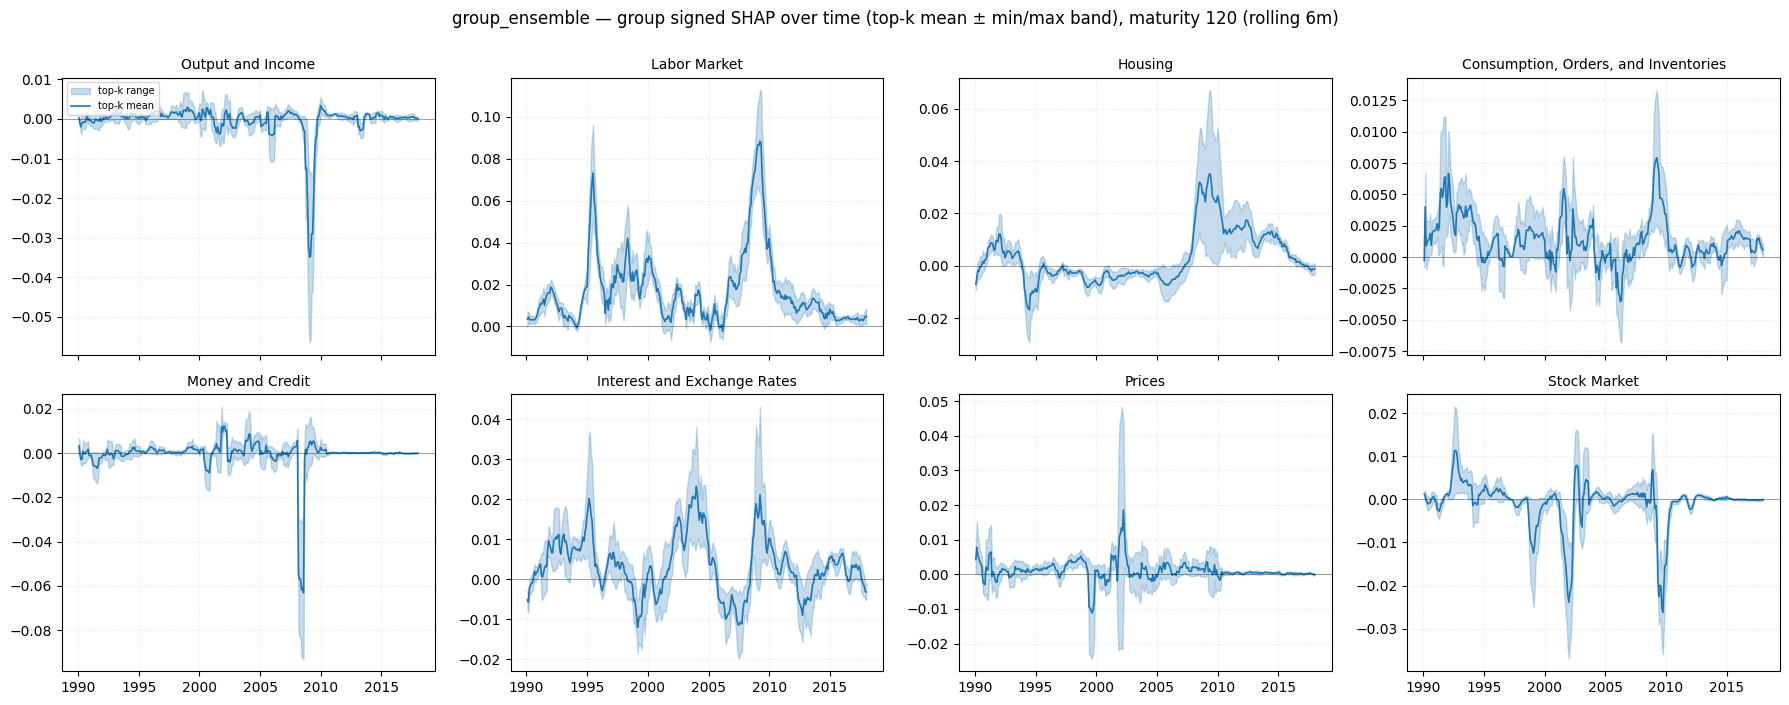

In [119]:
plot_maturity_t7 = '120'
smoothing_t7 = 6  # months rolling mean (applied to mean + band), 1 = disable

def ensemble_band(pg_m: pd.DataFrame) -> pd.DataFrame:
    """Per (date, group): mean / min / max of signed group SHAP across top-k seeds."""
    agg = (
        pg_m.groupby(['date', 'group'])['group_signed_shap']
        .agg(['mean', 'min', 'max', 'count'])
        .reset_index()
    )
    return agg

for name, d in tier7.items():
    pg = d['per_seed_group']
    pg_m = pg[pg['maturity'] == plot_maturity_t7]
    if pg_m.empty:
        print(f'{name}: no data at maturity {plot_maturity_t7} — skipping 7.1')
        continue
    band = ensemble_band(pg_m)
    fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, squeeze=False)
    for ax, g in zip(axes.ravel(), macro_group_order):
        gdf = band[band['group'] == g].sort_values('date')
        if gdf.empty:
            ax.text(0.5, 0.5, f'no data for {g}', ha='center', va='center')
            ax.set_title(g, fontsize=9)
            continue
        if smoothing_t7 and smoothing_t7 > 1:
            for col in ('mean', 'min', 'max'):
                gdf[col] = gdf[col].rolling(smoothing_t7, min_periods=1).mean()
        ax.fill_between(
            gdf['date'].values, gdf['min'].values, gdf['max'].values,
            alpha=0.25, color='tab:blue', label='top-k range',
        )
        ax.plot(gdf['date'].values, gdf['mean'].values, color='tab:blue',
                lw=1.2, label='top-k mean')
        ax.axhline(0, color='black', lw=0.5, alpha=0.5)
        ax.set_title(g, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.3)
        ax.xaxis.set_major_locator(YearLocator(5))
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    axes[0][0].legend(fontsize=7, loc='upper left')
    fig.suptitle(
        f'{name} — group signed SHAP over time (top-k mean ± min/max band), '
        f'maturity {plot_maturity_t7} (rolling {smoothing_t7}m)', y=1.00,
    )
    fig.tight_layout()
    plt.show()

### 7.2 — Per-date top-k spread per group

Identity-free replacement for per-seed boxplots. For each (date, group) compute `spread = max − min` across the top-k seeds' signed group SHAP at that date. Boxplot of those per-date spreads, one box per group. A tight box low on the y-axis ⇒ the top-k seeds consistently agree on that group's contribution; a box shifted high ⇒ substantial seed disagreement at typical dates. Forward is excluded; the y-axis is in the same signed-SHAP units as the rest of Tier 7.

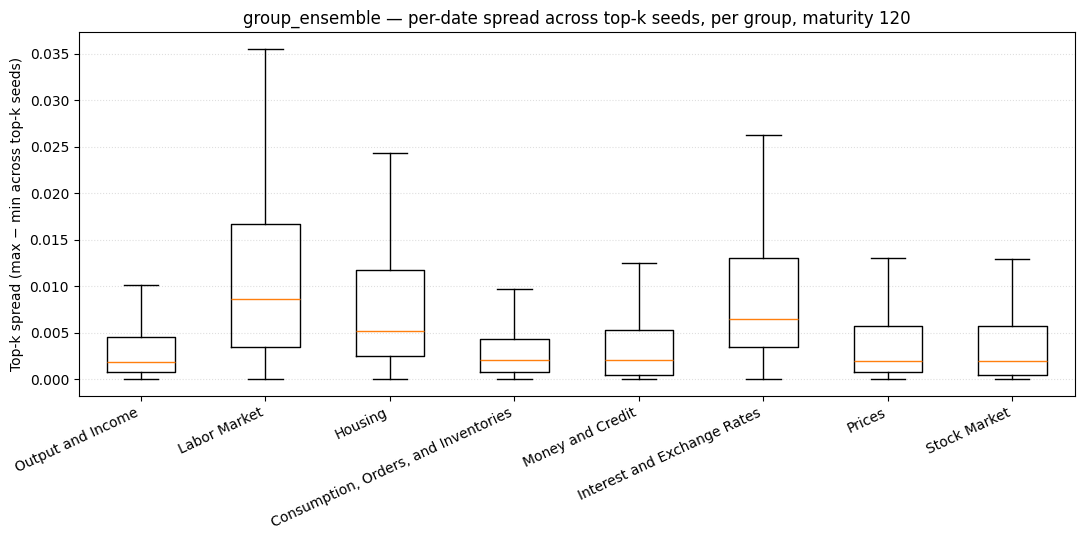

group_ensemble — per-date top-k spread summary:
                                      median    mean     max
group                                                       
Output and Income                     0.0019  0.0042  0.1095
Labor Market                          0.0086  0.0127  0.0748
Housing                               0.0052  0.0102  0.0942
Consumption, Orders, and Inventories  0.0021  0.0032  0.0303
Money and Credit                      0.0020  0.0063  0.2420
Interest and Exchange Rates           0.0065  0.0103  0.1212
Prices                                0.0020  0.0061  0.1968
Stock Market                          0.0020  0.0052  0.0730


In [120]:
for name, d in tier7.items():
    pg = d['per_seed_group']
    pg_m = pg[(pg['maturity'] == plot_maturity_t7) & (pg['group'] != 'forward')]
    if pg_m.empty:
        print(f'{name}: no data at maturity {plot_maturity_t7} — skipping 7.2')
        continue
    spread = (
        pg_m.groupby(['date', 'group'])['group_signed_shap']
        .agg(lambda s: float(s.max() - s.min()))
        .reset_index(name='topk_spread')
    )
    groups_here = [g for g in macro_group_order if g in set(spread['group'])]
    data = [spread[spread['group'] == g]['topk_spread'].values for g in groups_here]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    try:
        ax.boxplot(data, tick_labels=groups_here, showfliers=False, widths=0.55)
    except TypeError:
        ax.boxplot(data, labels=groups_here, showfliers=False, widths=0.55)
    ax.set_ylabel('Top-k spread (max − min across top-k seeds)')
    ax.set_title(
        f'{name} — per-date spread across top-k seeds, per group, maturity {plot_maturity_t7}'
    )
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
    fig.tight_layout()
    plt.show()

    summary = (
        spread.groupby('group')['topk_spread']
        .agg(['median', 'mean', 'max'])
        .reindex(groups_here)
        .round(4)
    )
    print(f'{name} — per-date top-k spread summary:')
    print(summary.to_string())

### 7.3 — Group-level coefficient of variation (vs feature-level)

For each (date, maturity, group), compute `std across seeds / |mean across seeds|` of signed group SHAP, then average over dates. Bars colored red if CoV > 1 (seed noise dominates signal), blue otherwise.

Side-by-side with the aggregated feature-level CoV (average over features within each group) so the "aggregation kills noise" claim is auditable — the aggregated-feature CoV is what you'd get if the signal was purely independent per feature; if the group-level CoV is significantly lower, it means the features within a group have correlated seed noise that cancels when summed.

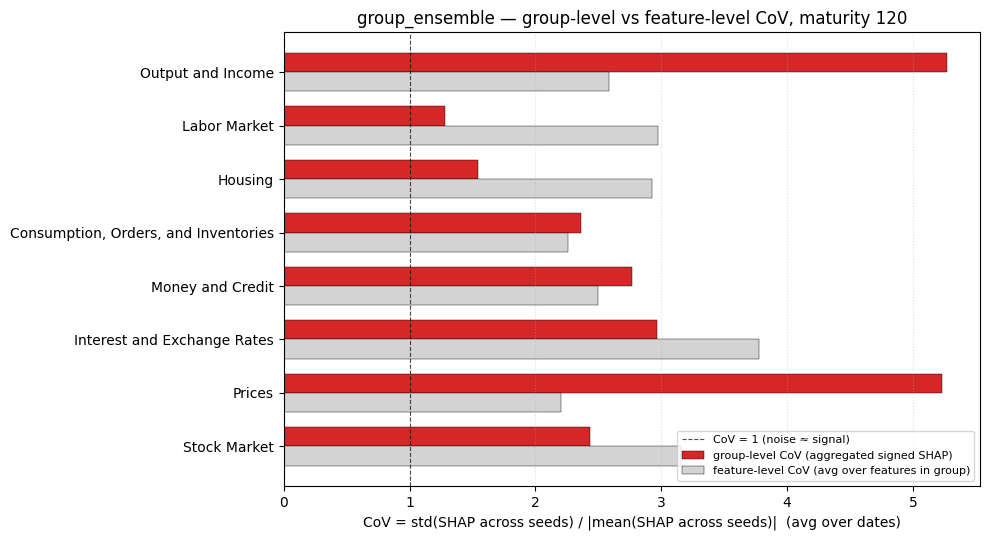

                                      group_cov  feature_cov_avg
Output and Income                         5.270            2.585
Labor Market                              1.277            2.976
Housing                                   1.543            2.923
Consumption, Orders, and Inventories      2.360            2.257
Money and Credit                          2.766            2.498
Interest and Exchange Rates               2.964            3.780
Prices                                    5.232            2.207
Stock Market                              2.431            3.154


In [121]:
def group_cov_from_per_seed(pg, maturity, eps=1e-6):
    """Group-level CoV: std-over-seeds / |mean-over-seeds| of signed group SHAP,
    averaged over dates. Returns a Series indexed by group."""
    pg_m = pg[pg['maturity'] == maturity]
    stats = (
        pg_m.groupby(['date', 'group'])['group_signed_shap']
        .agg(['mean', 'std']).reset_index()
    )
    stats['cov'] = stats['std'] / stats['mean'].abs().where(stats['mean'].abs() > eps)
    return stats.groupby('group')['cov'].mean()

def feature_cov_per_group(pss, maturity, eps=1e-6):
    """Average feature-level CoV within each group — the naive comparison baseline."""
    pss_m = pss[pss['maturity'] == maturity].copy()
    pss_m['group'] = pss_m['feature'].map(feature_group)
    stats = (
        pss_m.groupby(['date', 'feature', 'group'])['shap_value']
        .agg(['mean', 'std']).reset_index()
    )
    stats['cov'] = stats['std'] / stats['mean'].abs().where(stats['mean'].abs() > eps)
    per_feat = stats.groupby(['feature', 'group'])['cov'].mean().reset_index()
    return per_feat.groupby('group')['cov'].mean()

for name, d in tier7.items():
    pg = d['per_seed_group']
    pss = d['pss']
    if pg[pg['maturity'] == plot_maturity_t7].empty:
        print(f'{name}: no data at maturity {plot_maturity_t7} — skipping 7.3')
        continue

    group_cov = group_cov_from_per_seed(pg, plot_maturity_t7)
    feat_cov = feature_cov_per_group(pss, plot_maturity_t7)

    rows = [g for g in macro_group_order if g in group_cov.index]
    group_vals = [float(group_cov.loc[g]) for g in rows]
    feat_vals = [float(feat_cov.loc[g]) if g in feat_cov.index else np.nan for g in rows]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    y = np.arange(len(rows))
    colors_grp = ['tab:red' if v > 1.0 else 'tab:blue' for v in group_vals]
    ax.barh(y - 0.18, group_vals, 0.36, color=colors_grp, edgecolor='black',
            lw=0.3, label='group-level CoV (aggregated signed SHAP)')
    ax.barh(y + 0.18, feat_vals, 0.36, color='lightgrey', edgecolor='black',
            lw=0.3, label='feature-level CoV (avg over features in group)')
    ax.axvline(1.0, color='black', lw=0.8, linestyle='--', alpha=0.7,
               label='CoV = 1 (noise ≈ signal)')
    ax.set_yticks(y)
    ax.set_yticklabels(rows)
    ax.invert_yaxis()
    ax.set_xlabel('CoV = std(SHAP across seeds) / |mean(SHAP across seeds)|  (avg over dates)')
    ax.set_title(f'{name} — group-level vs feature-level CoV, maturity {plot_maturity_t7}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)
    fig.tight_layout()
    plt.show()

    print(
        pd.DataFrame({
            'group_cov': group_vals,
            'feature_cov_avg': feat_vals,
        }, index=rows).round(3).to_string()
    )

### 7.4 — Seed rank agreement at the group level

For each date, pivot group SHAP to an 8-dim per-seed vector (`|group_signed_shap|`) and compute pairwise Spearman across seeds. Average all pairs → per-date agreement. Compare to the feature-level agreement from 5.4 — if grouping really denoises the story, the group-level histogram should sit to the right of the feature-level one.

(Caveat: Spearman on 8 items has high variance. Use the median across dates as the summary statistic, not an individual date.)

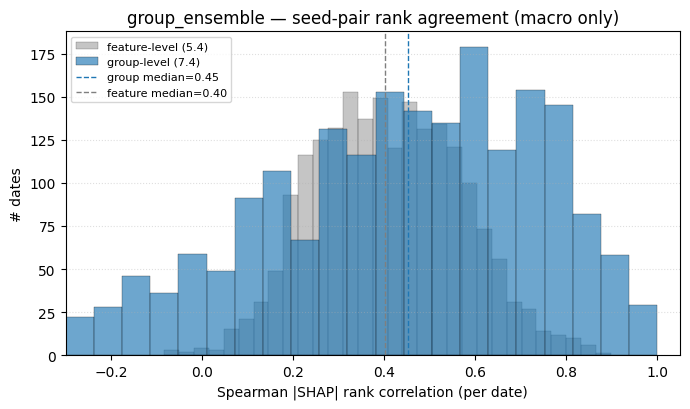

group_ensemble  GROUP:   mean_rho mean=0.411 median=0.452 min_rho mean=0.411
                FEATURE: mean_rho mean=0.408 median=0.402 min_rho mean=0.408


In [122]:
def group_rank_agreement(pg, macro_only=True):
    """Per-(date, maturity) pairwise Spearman of |signed group SHAP| across seeds."""
    pg = pg.copy()
    if macro_only:
        pg = pg[pg['group'] != 'forward']
    out = []
    for (date, maturity), grp in pg.groupby(['date', 'maturity']):
        pivot = grp.pivot_table(
            index='group', columns='seed',
            values='group_signed_shap', aggfunc='first',
        ).abs()
        if pivot.shape[0] < 3 or pivot.shape[1] < 2:
            continue
        cols = list(pivot.columns)
        corrs = []
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                rho = spearmanr(pivot[cols[i]].values, pivot[cols[j]].values).correlation
                if not np.isnan(rho):
                    corrs.append(rho)
        if corrs:
            out.append({
                'date': date, 'maturity': maturity,
                'mean_rho': float(np.mean(corrs)),
                'min_rho': float(np.min(corrs)),
                'n_pairs': len(corrs),
            })
    return pd.DataFrame(out)

fig, axes = plt.subplots(
    1, len(tier7), figsize=(7 * max(1, len(tier7)), 4.2),
    squeeze=False,
)
for ax, (name, d) in zip(axes[0], tier7.items()):
    agree_g = group_rank_agreement(d['per_seed_group'], macro_only=True)
    # feature-level comparison (reuse Tier 5 function with macro filter on)
    agree_f = seed_rank_agreement(d['pss'], macro_only=True)
    if agree_g.empty:
        ax.text(0.5, 0.5, 'Only one seed — skipping', ha='center', va='center')
        ax.set_title(name)
        continue
    ax.hist(agree_f['mean_rho'], bins=30, alpha=0.45, color='tab:gray',
            edgecolor='black', lw=0.3, label='feature-level (5.4)')
    ax.hist(agree_g['mean_rho'], bins=30, alpha=0.65, color='tab:blue',
            edgecolor='black', lw=0.3, label='group-level (7.4)')
    ax.axvline(agree_g['mean_rho'].median(), color='tab:blue', lw=1.0, linestyle='--',
               label=f'group median={agree_g["mean_rho"].median():.2f}')
    ax.axvline(agree_f['mean_rho'].median(), color='tab:gray', lw=1.0, linestyle='--',
               label=f'feature median={agree_f["mean_rho"].median():.2f}')
    ax.set_xlim(-0.3, 1.05)
    ax.set_xlabel('Spearman |SHAP| rank correlation (per date)')
    ax.set_ylabel('# dates')
    ax.set_title(f'{name} — seed-pair rank agreement (macro only)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
fig.tight_layout()
plt.show()

for name, d in tier7.items():
    agree_g = group_rank_agreement(d['per_seed_group'], macro_only=True)
    agree_f = seed_rank_agreement(d['pss'], macro_only=True)
    if agree_g.empty:
        print(f'{name}: only one seed per (date, maturity)')
        continue
    print(
        f'{name:14s}  '
        f'GROUP:   mean_rho mean={agree_g["mean_rho"].mean():.3f} '
        f'median={agree_g["mean_rho"].median():.3f} '
        f'min_rho mean={agree_g["min_rho"].mean():.3f}'
    )
    print(
        f'{"":14s}  '
        f'FEATURE: mean_rho mean={agree_f["mean_rho"].mean():.3f} '
        f'median={agree_f["mean_rho"].median():.3f} '
        f'min_rho mean={agree_f["min_rho"].mean():.3f}'
    )

## Tier 8 — Clean group ranking

Just the ranking: mean |SHAP| per group, sorted descending. Change `rank_run` and `rank_maturity` to switch which slice you're looking at. Set `rank_maturity = 'avg'` to average across all maturities in the run.

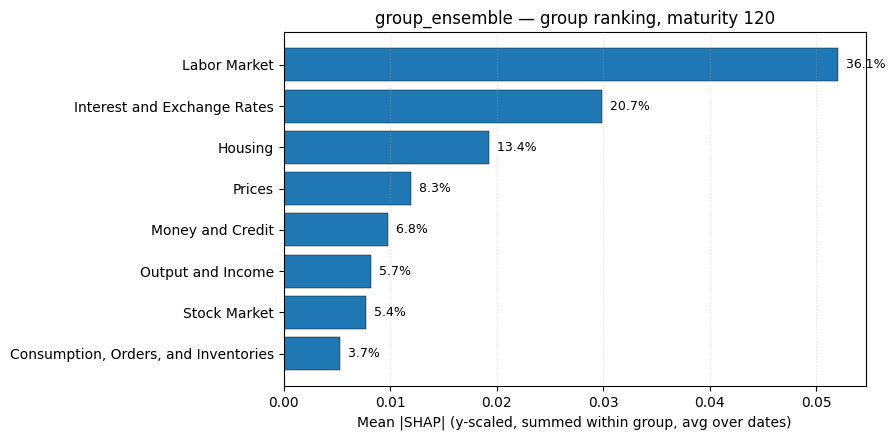

                                      mean_abs_shap  share_pct
group                                                         
Labor Market                                 0.0520       36.1
Interest and Exchange Rates                  0.0299       20.7
Housing                                      0.0192       13.4
Prices                                       0.0119        8.3
Money and Credit                             0.0098        6.8
Output and Income                            0.0082        5.7
Stock Market                                 0.0077        5.4
Consumption, Orders, and Inventories         0.0053        3.7


In [123]:
rank_run = 'group_ensemble'   # or 'macro_forward'
rank_maturity = '120'          # or 'avg' to average over all maturities
include_forward_rank = False

sm_rank = tier5_data[rank_run][2]  # shap_mean frame
df = sm_rank.assign(group=sm_rank['feature'].map(feature_group))
if not include_forward_rank:
    df = df[df['group'] != 'forward']

per_date_group = (
    df.groupby(['date', 'maturity', 'group'])['abs_mean_shap']
    .sum().reset_index(name='group_abs_shap')
)
if rank_maturity == 'avg':
    ranked = per_date_group.groupby('group')['group_abs_shap'].mean()
    mat_tag = 'averaged across maturities'
else:
    ranked = (
        per_date_group[per_date_group['maturity'] == rank_maturity]
        .groupby('group')['group_abs_shap'].mean()
    )
    mat_tag = f'maturity {rank_maturity}'

ranked = ranked.sort_values(ascending=True)  # ascending so the biggest bar is on top after invert
share = (ranked / ranked.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(ranked.index, ranked.values, color='tab:blue',
               edgecolor='black', lw=0.3)
for bar, g in zip(bars, ranked.index):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f'  {share.loc[g]:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP| (y-scaled, summed within group, avg over dates)')
ax.set_title(f'{rank_run} — group ranking, {mat_tag}')
ax.grid(True, axis='x', linestyle=':', alpha=0.4)
fig.tight_layout()
plt.show()

print(
    pd.DataFrame({'mean_abs_shap': ranked, 'share_pct': share})
    .sort_values('mean_abs_shap', ascending=False)
    .round(4)
    .to_string()
)

## Tier 9 — Forward vs macro attribution over time (spanning test)

The spanning hypothesis (Cochrane–Piazzesi 2005; Bauer–Hamilton 2018) says that the current forward curve contains all information useful for forecasting future bond returns — conditional on forwards, macro variables add nothing. If that's true, the model's attribution to macro features should be small and/or constant over time (i.e. any macro weight is spurious or arbitrary). If it fails — especially *conditionally*, in recessions or at the zero lower bound — the macro share of attribution should move with the business cycle.

For each (date, maturity) we aggregate mean |SHAP| into two blocks:

- `forward(t, m) = Σ_{f ∈ forward}  |SHAP(t, f, m)|`
- `macro(t, m)   = Σ_{f ∈ macro}    |SHAP(t, f, m)|`

and look at two views:

1. **9.1 — Levels.** Forward and macro |SHAP| plotted over time per maturity. Tells you the absolute weight each block gets, how they co-move, and where they diverge.
2. **9.2 — Macro share.** `macro / (macro + forward)` over time per maturity. This is the direct visual test: a flat share = spanning holds; regime-dependent spikes = conditional spanning failure.

NBER US recession bars are shaded behind each panel so regime co-movement is visible at a glance.

In [124]:
# NBER US recession dates (peak, trough) since 1990 — enough for all common OOS windows.
# Source: NBER Business Cycle Dating Committee.
nber_recessions = [
    ('1990-07-01', '1991-03-31'),
    ('2001-03-01', '2001-11-30'),
    ('2007-12-01', '2009-06-30'),
    ('2020-02-01', '2020-04-30'),
]
nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in nber_recessions]

# Shared knobs for Tier 9 (both 9.1 and 9.2 read these, so the cells can run
# independently without relying on execution order).
maturity_t9 = '120'
smoothing_t9 = 6      # months rolling mean; set to 1 to disable

def shade_recessions(ax, alpha=0.15, color='grey'):
    for start, end in nber_recessions:
        ax.axvspan(start, end, color=color, alpha=alpha, lw=0)

def forward_macro_over_time(sm: pd.DataFrame) -> pd.DataFrame:
    """Per (date, maturity): sum of mean |SHAP| over forward features and over
    macro features, plus the total and the macro share.
    """
    df = sm.assign(
        block=np.where(sm['feature'].map(is_forward), 'forward', 'macro')
    )
    agg = (
        df.groupby(['date', 'maturity', 'block'])['abs_mean_shap']
        .sum().unstack('block').fillna(0.0)
    )
    for col in ('forward', 'macro'):
        if col not in agg.columns:
            agg[col] = 0.0
    agg['total'] = agg['forward'] + agg['macro']
    agg['macro_share'] = agg['macro'] / agg['total'].replace(0, np.nan)
    return agg.reset_index()

tier9 = {
    name: forward_macro_over_time(sm)
    for name, (_, _, sm, _, _) in tier5_data.items()
}
for name, df in tier9.items():
    print(
        f'{name:14s} dates={df["date"].nunique()} '
        f'maturities={sorted(df["maturity"].unique())} '
        f'macro_share: mean={df["macro_share"].mean():.3f} '
        f'median={df["macro_share"].median():.3f}'
    )

macro_forward  dates=336 maturities=['120', '24', '36', '48', '60', '84'] macro_share: mean=0.478 median=0.460
group_ensemble dates=336 maturities=['120', '24', '36', '48', '60', '84'] macro_share: mean=0.424 median=0.394


### 9.1 — Forward and macro |SHAP| over time

Two lines per panel: total forward |SHAP| (sum over forward features) and total macro |SHAP| (sum over macro features), at a chosen maturity. One column per model. Smoothed with a rolling window so regime-scale movement is visible. NBER recessions shaded.

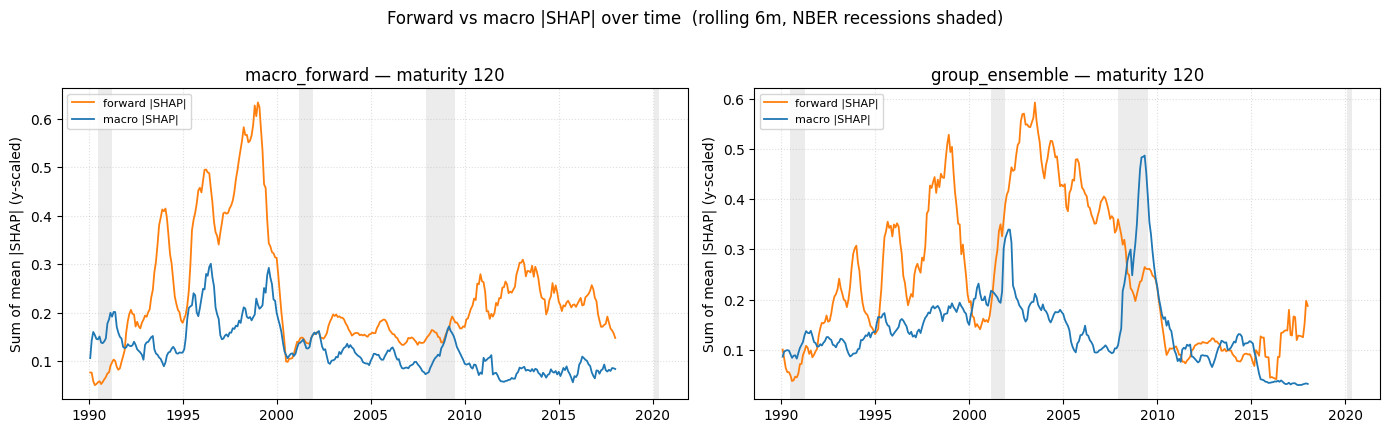

In [125]:
fig, axes = plt.subplots(
    1, len(tier9), figsize=(7 * len(tier9), 4.2), squeeze=False, sharey=False,
)
for ax, (name, df) in zip(axes[0], tier9.items()):
    sub = df[df['maturity'] == maturity_t9].sort_values('date').copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'no data for maturity {maturity_t9}',
                ha='center', va='center')
        ax.set_title(name)
        continue
    if smoothing_t9 and smoothing_t9 > 1:
        for col in ('forward', 'macro'):
            sub[col] = sub[col].rolling(smoothing_t9, min_periods=1).mean()
    shade_recessions(ax)
    ax.plot(sub['date'], sub['forward'], color='tab:orange', lw=1.3,
            label='forward |SHAP|')
    ax.plot(sub['date'], sub['macro'], color='tab:blue', lw=1.3,
            label='macro |SHAP|')
    ax.set_title(f'{name} — maturity {maturity_t9}')
    ax.set_ylabel('Sum of mean |SHAP| (y-scaled)')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.legend(loc='upper left', fontsize=8)
fig.suptitle(
    f'Forward vs macro |SHAP| over time  (rolling {smoothing_t9}m, NBER recessions shaded)',
    y=1.02,
)
fig.tight_layout()
plt.show()

### 9.2 — Macro share of attribution over time (the spanning test)

`macro_share(t, m) = macro(t, m) / (macro(t, m) + forward(t, m))`. A flat, low share ⇒ forwards dominate consistently — consistent with spanning. An upward-drifting or regime-dependent share ⇒ macros carry incremental information beyond what forwards do. The summary prints the mean/median macro share inside NBER recession months vs outside, as a quick regime-conditional check.

In [1]:
def in_recession(dates: pd.Series) -> pd.Series:
    """Boolean mask: True where the date falls inside any NBER recession window."""
    out = pd.Series(False, index=dates.index)
    for start, end in nber_recessions:
        out |= (dates >= start) & (dates <= end)
    return out

fig, axes = plt.subplots(
    1, len(tier9), figsize=(7 * len(tier9), 4.0), squeeze=False, sharey=True,
)
for ax, (name, df) in zip(axes[0], tier9.items()):
    sub = df[df['maturity'] == maturity_t9].sort_values('date').copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'no data for maturity {maturity_t9}',
                ha='center', va='center')
        ax.set_title(name)
        continue
    raw_share = sub['macro_share'].values
    if smoothing_t9 and smoothing_t9 > 1:
        sub['macro_share_smooth'] = (
            sub['macro_share'].rolling(smoothing_t9, min_periods=1).mean()
        )
    shade_recessions(ax)
    ax.plot(sub['date'], sub['macro_share'], color='tab:blue', lw=0.6,
            alpha=0.35, label='monthly')
    if smoothing_t9 and smoothing_t9 > 1:
        ax.plot(sub['date'], sub['macro_share_smooth'], color='tab:blue',
                lw=1.5, label=f'{smoothing_t9}m MA')
    ax.axhline(sub['macro_share'].mean(), color='black', lw=0.8, linestyle='--',
               alpha=0.8, label=f'sample mean={sub["macro_share"].mean():.2f}')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Macro share of |SHAP|')
    ax.set_title(f'{name} — maturity {maturity_t9}')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.legend(loc='upper left', fontsize=8)
fig.suptitle(
    'Macro share of SHAP attribution over time (NBER recessions shaded)', y=1.02,
)
fig.tight_layout()
plt.show()

# Regime-conditional summary: macro share inside recessions vs outside.
print('Macro share: in-recession vs out-of-recession means (higher in-rec ⇒ conditional spanning failure)')
print('-' * 90)
for name, df in tier9.items():
    for m in sorted(df['maturity'].unique(), key=lambda m: int(m)):
        sub = df[df['maturity'] == m].copy()
        mask = in_recession(sub['date'])
        in_r = sub.loc[mask, 'macro_share']
        out_r = sub.loc[~mask, 'macro_share']
        if len(in_r) == 0 or len(out_r) == 0:
            continue
        diff = in_r.mean() - out_r.mean()
        # simple 2-sample permutation test, 999 permutations
        all_vals = sub['macro_share'].dropna().values
        rng = np.random.default_rng(0)
        n_in = int(mask.sum())
        observed = diff
        null = []
        for _ in range(999):
            idx = rng.permutation(len(all_vals))
            null_in = all_vals[idx[:n_in]].mean()
            null_out = all_vals[idx[n_in:]].mean()
            null.append(null_in - null_out)
        p = float(np.mean(np.abs(null) >= abs(observed)))
        print(
            f'{name:14s} m={m:>3s}  '
            f'out_rec_mean={out_r.mean():.3f} (n={len(out_r):4d})  '
            f'in_rec_mean={in_r.mean():.3f} (n={len(in_r):3d})  '
            f'diff={diff:+.3f}  perm_p={p:.3f}'
        )

NameError: name 'pd' is not defined

### 9.3 — Term-structure summary: macro share across maturities (headline plot)

Single-model plot — change `tier9_model` at the top of the cell to switch between `'macro_forward'` and `'group_ensemble'`. X-axis = maturity; two lines = mean macro share out-of-recession vs in-recession, with the whole-sample mean as a dashed reference. This is the single plot that answers "how does the model's reliance on macro variables vary across the term structure, and does the business cycle change that pattern?". A flat line pair means the term structure of macro importance is invariant to regime; a large, maturity-dependent gap between the two lines points to a conditional-spanning pattern that varies across horizons.

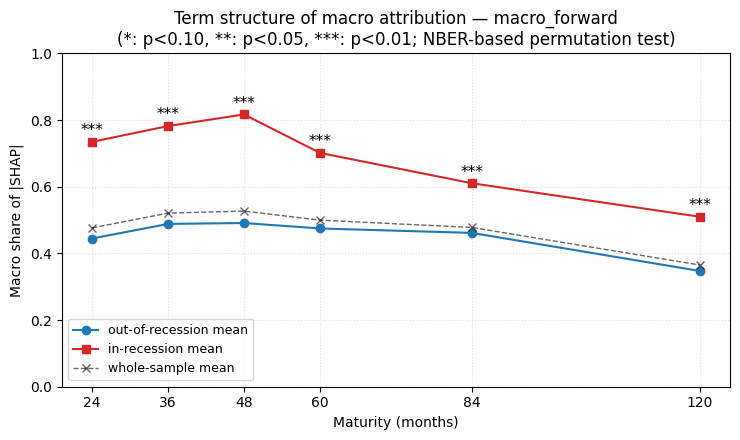

=== macro_forward ===
 maturity_m  n_out  out_mean  n_in  in_mean  sample_mean  diff  perm_p
         24    299     0.445    37    0.735        0.477 0.290     0.0
         36    299     0.488    37    0.782        0.521 0.294     0.0
         48    299     0.491    37    0.817        0.527 0.326     0.0
         60    299     0.475    37    0.701        0.500 0.227     0.0
         84    299     0.461    37    0.610        0.478 0.149     0.0
        120    299     0.347    37    0.510        0.365 0.163     0.0


In [127]:
# Which model to plot. Switch between keys of `tier9` and re-run this cell.
tier9_model = 'macro_forward'       # 'macro_forward' | 'group_ensemble'


def term_structure_summary(df: pd.DataFrame, n_perm: int = 999, seed: int = 0) -> pd.DataFrame:
    """Per maturity: out-of-rec / in-rec / diff macro share + permutation p-value."""
    rng = np.random.default_rng(seed)
    rows = []
    for m in sorted(df['maturity'].unique(), key=lambda m: int(m)):
        sub = df[df['maturity'] == m].dropna(subset=['macro_share']).copy()
        if sub.empty:
            continue
        mask = in_recession(sub['date'])
        in_r, out_r = sub.loc[mask, 'macro_share'], sub.loc[~mask, 'macro_share']
        if len(in_r) == 0 or len(out_r) == 0:
            continue
        diff = float(in_r.mean() - out_r.mean())
        vals = sub['macro_share'].values
        n_in = int(mask.sum())
        null = np.empty(n_perm)
        for k in range(n_perm):
            idx = rng.permutation(len(vals))
            null[k] = vals[idx[:n_in]].mean() - vals[idx[n_in:]].mean()
        p = float(np.mean(np.abs(null) >= abs(diff)))
        rows.append({
            'maturity_m': int(m),
            'n_out': int(len(out_r)),
            'out_mean': float(out_r.mean()),
            'n_in': int(len(in_r)),
            'in_mean': float(in_r.mean()),
            'sample_mean': float(sub['macro_share'].mean()),
            'diff': diff,
            'perm_p': p,
        })
    return pd.DataFrame(rows).sort_values('maturity_m').reset_index(drop=True)


if tier9_model not in tier9:
    raise KeyError(
        f'{tier9_model!r} not in tier9; available: {list(tier9)}'
    )

s = term_structure_summary(tier9[tier9_model])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
if s.empty:
    ax.text(0.5, 0.5, 'no data', ha='center', va='center')
else:
    x = s['maturity_m'].values
    ax.plot(x, s['out_mean'], marker='o', lw=1.5, color='tab:blue',
            label='out-of-recession mean')
    ax.plot(x, s['in_mean'], marker='s', lw=1.5, color='tab:red',
            label='in-recession mean')
    ax.plot(x, s['sample_mean'], marker='x', lw=1.0, color='black',
            alpha=0.6, linestyle='--', label='whole-sample mean')
    for xi, diff, p in zip(x, s['diff'], s['perm_p']):
        star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
        if star:
            y_top = max(
                float(s.loc[s['maturity_m'] == xi, 'in_mean'].iloc[0]),
                float(s.loc[s['maturity_m'] == xi, 'out_mean'].iloc[0]),
            )
            ax.text(xi, y_top + 0.02, star, ha='center', fontsize=11)
    ax.set_xticks(x)
ax.set_xlabel('Maturity (months)')
ax.set_ylabel('Macro share of |SHAP|')
ax.set_ylim(0, 1)
ax.set_title(
    f'Term structure of macro attribution — {tier9_model}\n'
    '(*: p<0.10, **: p<0.05, ***: p<0.01; NBER-based permutation test)'
)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='lower left', fontsize=9)
fig.tight_layout()
plt.show()

print(f'=== {tier9_model} ===')
print(
    s[['maturity_m', 'n_out', 'out_mean', 'n_in', 'in_mean',
       'sample_mean', 'diff', 'perm_p']]
    .round(3).to_string(index=False)
)

### 9.4 — Small multiples: macro share over time, one panel per maturity

Same quantity as 9.2, for a single model (set `tier9_model` at the top of the cell), laid out as a 3×2 grid across the six maturities. Useful as an appendix-style figure supporting the headline 9.3.

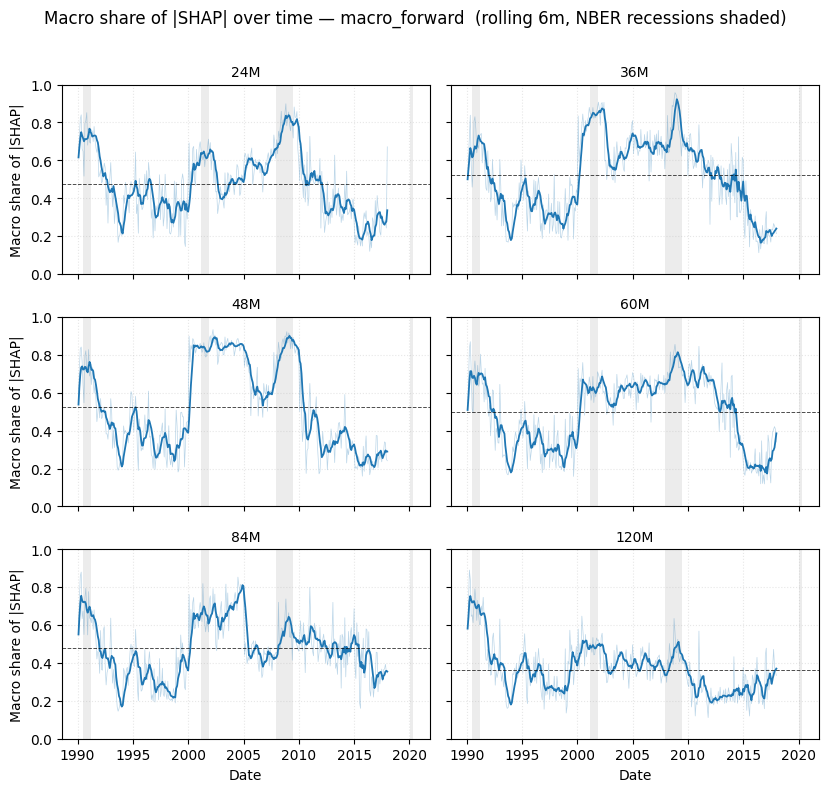

In [128]:
# Uses `tier9_model` set in cell 9.3. Override here if you want.
# tier9_model = 'macro_forward'       # 'macro_forward' | 'group_ensemble'

if tier9_model not in tier9:
    raise KeyError(f'{tier9_model!r} not in tier9; available: {list(tier9)}')

df_t9 = tier9[tier9_model]
all_maturities = sorted(df_t9['maturity'].unique(), key=lambda m: int(m))

n_rows, n_cols = 3, 2      # 2x3 panel as requested (3 rows, 2 columns)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4.2 * n_cols, 2.6 * n_rows),
    sharex=True, sharey=True,
)
axes_flat = axes.flatten()

for k, ax in enumerate(axes_flat):
    if k >= len(all_maturities):
        ax.axis('off')
        continue
    m = all_maturities[k]
    sub = df_t9[df_t9['maturity'] == m].sort_values('date').copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', fontsize=8)
        ax.set_title(f'{m}M', fontsize=10)
        continue
    if smoothing_t9 and smoothing_t9 > 1:
        sub['smooth'] = sub['macro_share'].rolling(smoothing_t9, min_periods=1).mean()
    shade_recessions(ax)
    ax.plot(sub['date'], sub['macro_share'], color='tab:blue', lw=0.5, alpha=0.3)
    if smoothing_t9 and smoothing_t9 > 1:
        ax.plot(sub['date'], sub['smooth'], color='tab:blue', lw=1.3)
    ax.axhline(sub['macro_share'].mean(), color='black', lw=0.7,
               linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_title(f'{m}M', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

# Axis labels only on outer panels.
for r in range(n_rows):
    axes[r][0].set_ylabel('Macro share of |SHAP|')
for c in range(n_cols):
    axes[-1][c].set_xlabel('Date')

fig.suptitle(
    f'Macro share of |SHAP| over time — {tier9_model}  '
    f'(rolling {smoothing_t9}m, NBER recessions shaded)',
    y=1.01,
)
fig.tight_layout()
plt.show()

## Tier 10 — Group-Shapley cross-check

The Tier 1 / 1c / 2 / 6 / 8 / 9 figures all aggregate per-feature DeepSHAP values into group-level numbers *post hoc* (sum or mean across features within a group). That is axiomatically valid — Shapley values are additive by linearity — but it has a well-known weakness when the within-group features carry a common signal: DeepSHAP spreads the shared "group information" credit across the substitutes, so each correlated series gets a small individual value. Summing recovers the group total correctly, but the distribution of credit inside the group becomes noisy and cross-group comparisons are sensitive to how many features each group happens to contain.

**Grouped Shapley** avoids that by redefining the cooperative game so the players are *groups*, not features. For forward + 8 FRED-MD groups we have 9 players and 2⁹ = 512 coalitions per `(date, maturity)` — enumerated exactly rather than approximated. "Mask group g" means replace that slice of the model's input with the corresponding background mean:

- `GroupEnsembleANNWrapper` has one input tensor per group, so masking is at the tensor level (natural).
- `MacroForwardANNWrapper` has a single pooled FRED input, so masking clamps the columns belonging to that FRED-MD group to their training-window means.

This tier (a) runs the exact group-Shapley computation for both models and (b) compares group-Shapley shares against the naive-aggregation shares from Tier 1c. A finding that survives both aggregations is robust; one that appears only under naive aggregation is a feature-count / redundancy artefact and should be flagged as such in the discussion.

Implementation: `utils/group_shap_runner.compute_group_shap_for_run`. Output layout mirrors DeepSHAP: `artifacts/group_shap/<run_name>/<orchestrator_ts>/group_shap_mean.parquet` (and friends). The runner is resume-friendly and keyed on the orchestrator run timestamp, so repeated calls only fill gaps.

In [130]:
# ── Tier 10 compute: exact group Shapley for both wrappers ──────────────
# Reuses the same orchestrator checkpoints as DeepSHAP. Each (date, maturity)
# enumerates all 512 coalitions per top-k seed; outputs land under
# artifacts/group_shap/<run_name>/<orchestrator_ts>/. Resume-friendly.

from utils.group_shap_runner import GroupShapRunConfig, compute_group_shap_for_run
import time

tier10_runs = [
    'macro_forward_ann_valid_3_5seeds',
    'group_ensemble_ann_valid_fwd3_grp3_5seeds',
]
tier10_maturities = ['24', '36', '48', '60', '84', '120']   # match DeepSHAP sweep

tier10_summaries = {}
for rn in tier10_runs:
    t0 = time.time()
    cfg_gs = GroupShapRunConfig(
        orchestrator_run_dir=latest_run_dir(rn),
        dates='all',
        maturities=tier10_maturities,
        background_size=128,
        apply_y_scaling=True,
        y_center_default=False,
        output_root=str(REPO_ROOT / 'artifacts' / 'group_shap'),
        overwrite=False,
        progress=True,
        save_per_seed=True,
    )
    s = compute_group_shap_for_run(cfg_gs, X=X, dates=dates)
    tier10_summaries[rn] = s
    print(
        f'{rn}: additivity_max={s["additivity_error_max"]:.2e} '
        f'dates_written={s["n_dates_written_this_call"]} '
        f'already_present={s["n_dates_already_present"]} '
        f'elapsed={time.time() - t0:.0f}s'
    )
    print(f'  players: {s["players"]}')
    print(f'  output: {s["output_dir"]}')
    print()

tier10_summaries

macro_forward_ann_valid_3_5seeds: additivity_max=2.22e-16 dates_written=336 already_present=0 elapsed=34s
  players: ['forward', 'Consumption, Orders, and Inventories', 'Housing', 'Interest and Exchange Rates', 'Labor Market', 'Money and Credit', 'Output and Income', 'Prices', 'Stock Market']
  output: /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/macro_forward_ann_valid_3_5seeds/20260422_103724



group_ensemble_ann_valid_fwd3_grp3_5seeds: additivity_max=3.33e-16 dates_written=336 already_present=0 elapsed=67s
  players: ['forward', 'Consumption, Orders, and Inventories', 'Housing', 'Interest and Exchange Rates', 'Labor Market', 'Money and Credit', 'Output and Income', 'Prices', 'Stock Market']
  output: /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101



{'macro_forward_ann_valid_3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/macro_forward_ann_valid_3_5seeds/20260422_103724',
  'n_dates_total': 336,
  'n_dates_written_this_call': 336,
  'n_dates_already_present': 0,
  'elapsed_s': 34.21,
  'additivity_error_mean': 1.0229175320841592e-17,
  'additivity_error_max': 2.220446049250313e-16,
  'players': ['forward',
   'Consumption, Orders, and Inventories',
   'Housing',
   'Interest and Exchange Rates',
   'Labor Market',
   'Money and Credit',
   'Output and Income',
   'Prices',
   'Stock Market']},
 'group_ensemble_ann_valid_fwd3_grp3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101',
  'n_dates_total': 336,
  'n_dates_written_this_call': 336,
  'n_dates_already_present': 0,
  'elapsed_s': 66.7,
  'additivity_error_m

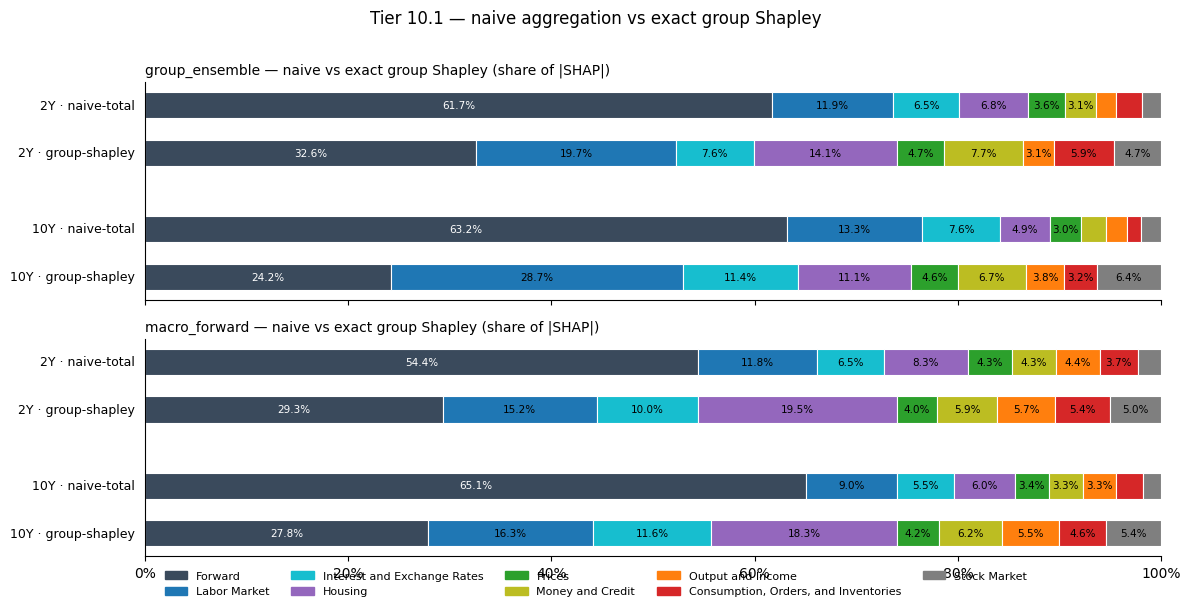


=== group_ensemble · 24M · naive vs group-Shapley shares (%) ===
                                      naive-total_%  group-shapley_%  diff_pp
group                                                                        
forward                                       61.72            32.57   -29.15
Labor Market                                  11.91            19.69     7.78
Interest and Exchange Rates                    6.49             7.64     1.15
Housing                                        6.81            14.08     7.27
Prices                                         3.61             4.66     1.05
Money and Credit                               3.07             7.74     4.67
Output and Income                              1.96             3.08     1.12
Consumption, Orders, and Inventories           2.56             5.87     3.31
Stock Market                                   1.87             4.67     2.80

=== group_ensemble · 120M · naive vs group-Shapley shares (%) ===
         

In [131]:
# ── Tier 10.1: group-Shapley vs naive aggregation (2Y & 10Y, per model) ──
# Side-by-side stacked-bar view. For each (model, maturity) we draw two rows:
#   - "naive-total"   : per-feature DeepSHAP |mean_seeds SHAP| summed within group, averaged across dates.
#                       Matches the "total" row in Tier 1.
#   - "group-Shapley" : exact Shapley over the 9-player group game,
#                       |mean_seeds group_SHAP| averaged across dates.
# Bars are normalised to 100% within the row so 2Y and 10Y are directly
# comparable and the two aggregations can be read side-by-side.
# ────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tier10_cmp_maturities = ['24', '120']
tier10_cmp_label_min = 3.0          # hide labels smaller than this (%)

_t10_runs = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}


def _latest(root: Path) -> Path:
    return sorted(p for p in root.iterdir() if p.is_dir())[-1]


def _naive_group_shares(run_name: str, mats: list[str]) -> pd.DataFrame:
    """Tier-1 'total' aggregation: sum |mean_seeds SHAP| within block per date, then mean across dates."""
    d = _latest(REPO_ROOT / 'artifacts' / 'shap' / run_name)
    sm = pd.read_parquet(d / 'shap_mean.parquet')
    sm = sm[sm['maturity'].isin(mats)].copy()

    def _block(feat):
        parts = feat.split('::')
        if parts[0] == 'forward':
            return 'forward'
        if parts[0] == 'fred' and len(parts) >= 3:
            return parts[1]
        if len(parts) >= 2:
            return parts[0]
        return parts[0]

    sm['group'] = sm['feature'].map(_block)
    per_date = sm.groupby(['maturity', 'date', 'group'])['abs_mean_shap'].sum()
    agg = per_date.groupby(['maturity', 'group']).mean().reset_index(name='importance')
    return agg.assign(aggregation='naive-total', run=run_name)


def _group_shapley_shares(run_name: str, mats: list[str]) -> pd.DataFrame:
    """Exact group Shapley: |mean_seeds group_SHAP| averaged across dates."""
    d = _latest(REPO_ROOT / 'artifacts' / 'group_shap' / run_name)
    gsm = pd.read_parquet(d / 'group_shap_mean.parquet')
    gsm = gsm[gsm['maturity'].isin(mats)].copy()
    agg = gsm.groupby(['maturity', 'group'])['abs_mean_shap'].mean().reset_index(
        name='importance'
    )
    return agg.assign(aggregation='group-shapley', run=run_name)


# Pool both aggregations for both models.
frames = []
for key, rn in _t10_runs.items():
    try:
        frames.append(_naive_group_shares(rn, tier10_cmp_maturities).assign(model=key))
    except FileNotFoundError:
        print(f'[skip] no DeepSHAP output for {rn}')
    try:
        frames.append(_group_shapley_shares(rn, tier10_cmp_maturities).assign(model=key))
    except FileNotFoundError:
        print(f'[skip] no group-Shapley output for {rn}')
cmp = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

if cmp.empty:
    raise RuntimeError(
        'No data. Run cell 7 (DeepSHAP) and the Tier 10 compute cell above first.'
    )

# Order groups by total naive importance across maturities so forward sits first.
_macro_order = (
    cmp[(cmp['group'] != 'forward') & (cmp['aggregation'] == 'naive-total')]
    .groupby('group')['importance'].sum().sort_values(ascending=False).index.tolist()
)
block_order = ['forward'] + _macro_order

_classic_blue_first = [
    '#1f77b4', '#17becf', '#9467bd', '#2ca02c',
    '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
    '#8c564b', '#c5b0d5',
]
block_colors_t10 = {'forward': '#3a4a5c'}
for i, g in enumerate(_macro_order):
    block_colors_t10[g] = _classic_blue_first[i % len(_classic_blue_first)]


def _row_shares(df_row: pd.DataFrame) -> pd.Series:
    s = df_row.set_index('group')['importance'].reindex(block_order).fillna(0.0)
    total = s.sum()
    return s / total if total > 0 else s


def _draw_row(ax, shares: pd.Series, y: float, label: str):
    left = 0.0
    for blk in block_order:
        w = float(shares.loc[blk])
        if w <= 0:
            continue
        ax.barh(y, w, left=left, height=0.55,
                color=block_colors_t10[blk], edgecolor='white', linewidth=0.8)
        if w * 100 >= tier10_cmp_label_min:
            ax.text(left + w / 2, y, f'{w * 100:.1f}%',
                    ha='center', va='center',
                    fontsize=7.5,
                    color='white' if blk == 'forward' else 'black')
        left += w
    ax.text(-0.01, y, label, ha='right', va='center', fontsize=9)


n_models = cmp['model'].nunique()
n_mats = len(tier10_cmp_maturities)
fig, axes = plt.subplots(
    n_models, 1, figsize=(12, 1.4 + 1.1 * n_mats * n_models),
    squeeze=False, sharex=True,
)
for ax_i, model_key in enumerate(sorted(cmp['model'].unique())):
    ax = axes[ax_i, 0]
    row_labels = []
    y_cursor = 0.0
    for mat_i, mat in enumerate(tier10_cmp_maturities):
        if mat_i > 0:
            y_cursor += 0.6
        for agg_i, agg in enumerate(['naive-total', 'group-shapley']):
            sub = cmp[
                (cmp['model'] == model_key)
                & (cmp['maturity'] == mat)
                & (cmp['aggregation'] == agg)
            ]
            shares = _row_shares(sub) if len(sub) else pd.Series(
                0.0, index=block_order
            )
            lbl = f'{int(mat)//12}Y · {agg}'
            row_labels.append((y_cursor, lbl))
            _draw_row(ax, shares, -y_cursor, lbl)
            y_cursor += 1.0
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
    ax.set_title(f'{model_key} — naive vs exact group Shapley (share of |SHAP|)',
                 loc='left', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=block_colors_t10[b]) for b in block_order]
labels = [b.capitalize() if b == 'forward' else b for b in block_order]
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=min(len(block_order), 5), frameon=False, fontsize=8)
fig.suptitle('Tier 10.1 — naive aggregation vs exact group Shapley',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# Printable comparison.
for model_key in sorted(cmp['model'].unique()):
    for mat in tier10_cmp_maturities:
        rows = {}
        for agg in ['naive-total', 'group-shapley']:
            sub = cmp[
                (cmp['model'] == model_key)
                & (cmp['maturity'] == mat)
                & (cmp['aggregation'] == agg)
            ]
            if sub.empty:
                continue
            shares = _row_shares(sub)
            rows[f'{agg}_%'] = shares * 100
        if not rows:
            continue
        tbl = pd.DataFrame(rows).round(2)
        tbl['diff_pp'] = (tbl.get('group-shapley_%', 0) - tbl.get('naive-total_%', 0)).round(2)
        print(f'\n=== {model_key} · {mat}M · naive vs group-Shapley shares (%) ===')
        print(tbl.to_string())

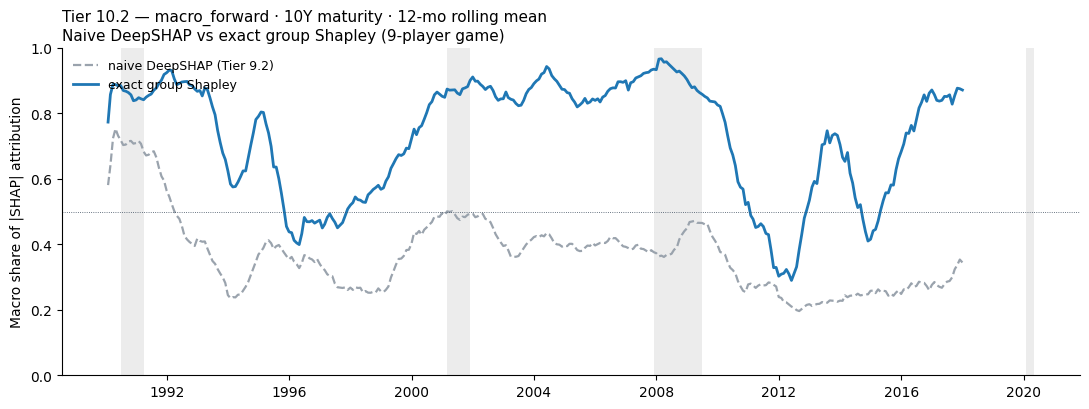

=== Tier 10.2 · macro_forward · 120M ===
  corr(naive, group_shapley) = +0.547
  mean(group_shapley - naive) = +0.365 pp
  max|diff| = 0.759 pp
  naive      mean share = 0.365
  group-shap mean share = 0.731


In [132]:
# ── Tier 10.2: forward-vs-macro share over time, group-Shapley edition ───
# Mirror of Tier 9.2 but using exact group Shapley instead of naive
# aggregation. The 'macro share' series is the sum of |mean_seeds group_SHAP|
# over the 8 FRED-MD groups divided by the sum over all 9 players, per
# (date, maturity). If the two series agree with Tier 9.2's curve the
# spanning-hypothesis conclusion is robust; systematic gaps flag where naive
# aggregation is being distorted by within-group redundancy.
# ────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tier10_ts_model = 'macro_forward'           # 'macro_forward' | 'group_ensemble'
tier10_ts_maturity = '120'                  # which maturity to plot
tier10_ts_smoothing = 12                    # months, rolling mean

_t10_ts_runs = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}
if tier10_ts_model not in _t10_ts_runs:
    raise KeyError(tier10_ts_model)

_gs_dir = sorted(
    (REPO_ROOT / 'artifacts' / 'group_shap' / _t10_ts_runs[tier10_ts_model]).iterdir()
)[-1]
_ds_dir = sorted(
    (REPO_ROOT / 'artifacts' / 'shap' / _t10_ts_runs[tier10_ts_model]).iterdir()
)[-1]

gsm = pd.read_parquet(_gs_dir / 'group_shap_mean.parquet')
gsm = gsm[gsm['maturity'] == tier10_ts_maturity].copy()
gsm['date'] = pd.to_datetime(gsm['date'])

# Group-Shapley macro share per date.
gsm['block'] = np.where(gsm['group'] == 'forward', 'forward', 'macro')
block_totals = (
    gsm.groupby(['date', 'block'])['abs_mean_shap'].sum().unstack('block').fillna(0.0)
)
block_totals['macro_share'] = block_totals['macro'] / (
    block_totals['forward'] + block_totals['macro']
).replace(0, np.nan)
gs_share = block_totals['macro_share'].rename('group_shapley')

# DeepSHAP naive macro share (same metric as Tier 9.2) for comparison.
sm = pd.read_parquet(_ds_dir / 'shap_mean.parquet')
sm = sm[sm['maturity'] == tier10_ts_maturity].copy()
sm['date'] = pd.to_datetime(sm['date'])
sm['block'] = np.where(
    sm['feature'].str.split('::').str[0] == 'forward',
    'forward', 'macro',
)
blk = sm.groupby(['date', 'block'])['abs_mean_shap'].sum().unstack('block').fillna(0.0)
blk['macro_share'] = blk['macro'] / (blk['forward'] + blk['macro']).replace(0, np.nan)
ds_share = blk['macro_share'].rename('naive_deepshap')

ts = pd.concat([gs_share, ds_share], axis=1).sort_index()
if tier10_ts_smoothing > 1:
    ts_smooth = ts.rolling(tier10_ts_smoothing, min_periods=1).mean()
else:
    ts_smooth = ts

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ts_smooth.index, ts_smooth['naive_deepshap'],
        color='#9aa3ad', linestyle='--', linewidth=1.6,
        label='naive DeepSHAP (Tier 9.2)')
ax.plot(ts_smooth.index, ts_smooth['group_shapley'],
        color='#1f77b4', linewidth=2.0,
        label='exact group Shapley')
ax.axhline(0.5, color='#3a4a5c', linewidth=0.6, linestyle=':')

# NBER recession shading — reuse Tier 9 helper if present.
if 'shade_recessions' in globals():
    try:
        shade_recessions(ax)
    except Exception:
        pass

ax.set_ylim(0, 1)
ax.set_ylabel('Macro share of |SHAP| attribution')
ax.set_xlabel('')
ax.set_title(
    f'Tier 10.2 — {tier10_ts_model} · {int(tier10_ts_maturity)//12}Y maturity · '
    f'{tier10_ts_smoothing}-mo rolling mean\n'
    f'Naive DeepSHAP vs exact group Shapley (9-player game)',
    fontsize=11, loc='left',
)
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Summary stats.
joined = ts.dropna()
corr = joined.corr().loc['naive_deepshap', 'group_shapley']
mean_diff = (joined['group_shapley'] - joined['naive_deepshap']).mean()
max_diff = (joined['group_shapley'] - joined['naive_deepshap']).abs().max()
print(f'=== Tier 10.2 · {tier10_ts_model} · {tier10_ts_maturity}M ===')
print(f'  corr(naive, group_shapley) = {corr:+.3f}')
print(f'  mean(group_shapley - naive) = {mean_diff:+.3f} pp')
print(f'  max|diff| = {max_diff:.3f} pp')
print(f'  naive      mean share = {joined["naive_deepshap"].mean():.3f}')
print(f'  group-shap mean share = {joined["group_shapley"].mean():.3f}')